# Milestone 1 — Data Collection, Labeling & Feature Engineering

---
## deep_api_extractor

### Deep API Call Extractor for TensorFlow, PyTorch, and JAX

Extracts deeply-qualified API call sites from framework source repos
for training multi-class function classification models.

Produces a unified dataset of (code_context, full_api_path, metadata) tuples
suitable for training sequence classification models (CNN+LSTM, Transformers, etc.)

Usage:
    # Clone repos first:
    # git clone https://github.com/tensorflow/tensorflow.git
    # git clone https://github.com/pytorch/pytorch.git
    # git clone https://github.com/jax-ml/jax.git

    python deep_api_extractor.py \
        --tf-repo ./tensorflow \
        --pytorch-repo ./pytorch \
        --jax-repo ./jax \
        --output ./unified_dataset.jsonl \
        --include-synthetic

In [1]:
import ast
import os
import re
import json
import yaml
import logging
import hashlib
import argparse
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional
from collections import defaultdict

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Data Structures

In [2]:
@dataclass
class APICallSite:
    """A single extracted API call with full context."""
    framework: str                  # "tensorflow", "pytorch", "jax"
    api_path: str                   # Full qualified path, e.g. "tensorflow.distribute.experimental.rpc.kernels.gen_rpc_ops.rpc_client"
    code_context: str               # The surrounding code (call + a few lines of context)
    call_expression: str            # Just the call itself, e.g. "gen_rpc_ops.rpc_client(...)"
    source_file: str                # Where it was found
    line_number: int                # Line in source file
    num_args: int                   # Number of positional args
    kwarg_names: list               # Names of keyword arguments
    depth_level: int                # How deep the API path goes
    api_category: str               # "ops", "nn", "distributed", "autograd", "compiler", "io", "other"
    is_internal: bool               # Whether it uses _private or internal APIs
    is_synthetic: bool = False      # Whether this was synthetically generated

    @property
    def unique_id(self):
        content = f"{self.framework}:{self.api_path}:{self.code_context}"
        return hashlib.md5(content.encode()).hexdigest()

#### Base AST Extractor

In [3]:
class BaseDeepCallExtractor(ast.NodeVisitor):
    """
    Base class for framework-specific AST extractors.

    Handles:
    - Import tracking (import X, from X import Y, from X import Y as Z)
    - Call resolution (resolving chained attribute access to full paths)
    - Context extraction (surrounding lines for each call site)
    """

    FRAMEWORK = "base"
    ROOTS = set()
    COMMON_ALIASES = {}
    INTERNAL_MARKERS = {"_", "__"}

    # Categories for classifying API paths
    CATEGORY_PATTERNS = {}

    def __init__(self, source_code: str, file_path: str):
        self.source = source_code
        self.source_lines = source_code.splitlines()
        self.file_path = file_path
        self.imports = {}           # alias -> full module path
        self.from_imports = {}      # alias -> full qualified name
        self.star_imports = []      # modules imported with *
        self.calls = []             # extracted APICallSite instances

        # Pre-populate common aliases
        for alias, full_path in self.COMMON_ALIASES.items():
            self.from_imports[alias] = full_path

    def extract(self):
        """Parse the source and extract all deep API calls."""
        try:
            tree = ast.parse(self.source)
            self.visit(tree)
        except SyntaxError:
            logger.debug(f"Syntax error in {self.file_path}, skipping")
        return self.calls

    def visit_Import(self, node):
        """Track: import torch, import tensorflow as tf"""
        for alias in node.names:
            name = alias.asname or alias.name
            self.imports[name] = alias.name
        self.generic_visit(node)

    def visit_ImportFrom(self, node):
        """Track: from torch.nn import functional as F"""
        if node.module is None:
            self.generic_visit(node)
            return

        for alias in node.names:
            if alias.name == "*":
                self.star_imports.append(node.module)
                continue
            name = alias.asname or alias.name
            self.from_imports[name] = f"{node.module}.{alias.name}"

        self.generic_visit(node)

    def visit_Call(self, node):
        """Extract and resolve every function call."""
        full_path = self._resolve_call_path(node.func)

        if full_path and self._is_framework_call(full_path):
            context = self._get_context(node)
            call_expr = self._get_call_expression(node)
            api_path = self._normalize_path(full_path)

            site = APICallSite(
                framework=self.FRAMEWORK,
                api_path=api_path,
                code_context=context,
                call_expression=call_expr,
                source_file=self.file_path,
                line_number=node.lineno,
                num_args=len(node.args),
                kwarg_names=[kw.arg for kw in node.keywords if kw.arg],
                depth_level=api_path.count("."),
                api_category=self._categorize(api_path),
                is_internal=self._is_internal(api_path),
            )
            self.calls.append(site)

        self.generic_visit(node)

    def _resolve_call_path(self, node) -> Optional[str]:
        """Recursively resolve a call node to its full dotted path."""
        if isinstance(node, ast.Name):
            # Simple name: could be a from-import or a direct import
            name = node.id
            if name in self.from_imports:
                return self.from_imports[name]
            if name in self.imports:
                return self.imports[name]
            # Check star imports
            for mod in self.star_imports:
                if self._is_framework_root(mod):
                    return f"{mod}.{name}"
            return name

        elif isinstance(node, ast.Attribute):
            # Chained: something.attr
            parent = self._resolve_call_path(node.value)
            if parent:
                return f"{parent}.{node.attr}"
            # If parent resolution failed, try to build from attribute chain
            chain = self._get_attribute_chain(node)
            if chain:
                return chain
            return None

        elif isinstance(node, ast.Subscript):
            # Handle torch.ops.aten["add"] style access
            parent = self._resolve_call_path(node.value)
            if parent and isinstance(node.slice, ast.Constant):
                return f"{parent}.{node.slice.value}"
            return parent

        return None

    def _get_attribute_chain(self, node) -> Optional[str]:
        """Build full dotted path from chained attribute access."""
        parts = []
        current = node
        while isinstance(current, ast.Attribute):
            parts.append(current.attr)
            current = current.value
        if isinstance(current, ast.Name):
            parts.append(current.id)
            # Resolve the root
            root = parts[-1]
            if root in self.from_imports:
                parts[-1] = self.from_imports[root]
            elif root in self.imports:
                parts[-1] = self.imports[root]
            return ".".join(reversed(parts))
        return None

    def _is_framework_call(self, path: str) -> bool:
        """Check if the resolved path belongs to this framework."""
        for root in self.ROOTS:
            if path.startswith(root + ".") or path == root:
                return True
        return False

    def _is_framework_root(self, module: str) -> bool:
        """Check if a module belongs to this framework."""
        for root in self.ROOTS:
            if module.startswith(root):
                return True
        return False

    def _get_context(self, node, context_lines=3) -> str:
        """Extract surrounding lines of code for context."""
        start = max(0, node.lineno - 1 - context_lines)
        end = min(len(self.source_lines), node.end_lineno + context_lines if node.end_lineno else node.lineno + context_lines)
        return "\n".join(self.source_lines[start:end])

    def _get_call_expression(self, node) -> str:
        """Extract just the call expression text."""
        try:
            start_line = node.lineno - 1
            end_line = node.end_lineno if node.end_lineno else node.lineno
            lines = self.source_lines[start_line:end_line]
            if lines:
                # Adjust first and last line offsets
                if len(lines) == 1:
                    return lines[0][node.col_offset:node.end_col_offset]
                else:
                    lines[0] = lines[0][node.col_offset:]
                    if node.end_col_offset:
                        lines[-1] = lines[-1][:node.end_col_offset]
                    return "\n".join(lines)
        except (IndexError, TypeError):
            pass
        return ""

    def _normalize_path(self, path: str) -> str:
        """Normalize the API path (framework-specific override point)."""
        return path

    def _categorize(self, path: str) -> str:
        """Categorize an API path into a functional area."""
        path_lower = path.lower()
        for category, patterns in self.CATEGORY_PATTERNS.items():
            for pattern in patterns:
                if pattern in path_lower:
                    return category
        return "other"

    def _is_internal(self, path: str) -> bool:
        """Check if path uses internal/private APIs."""
        parts = path.split(".")
        return any(
            part.startswith("_") and not part.startswith("__init__")
            for part in parts
        )

#### TensorFlow Extractor

In [4]:
class TensorFlowExtractor(BaseDeepCallExtractor):
    """
    Extracts deep TF calls including:
    - gen_*_ops.* (generated op wrappers)
    - tf.raw_ops.* (raw operations)
    - tf.distribute.experimental.rpc.kernels.*
    - _pywrap_* (C++ bindings)
    - Internal test helpers and framework calls
    """

    FRAMEWORK = "tensorflow"
    ROOTS = {"tf", "tensorflow", "keras"}
    COMMON_ALIASES = {
        "tf": "tensorflow",
        "K": "tensorflow.keras.backend",
        "layers": "tensorflow.keras.layers",
    }

    CATEGORY_PATTERNS = {
        "ops": ["gen_", "raw_ops", "_ops.", "math_ops", "array_ops", "nn_ops", "string_ops"],
        "nn": ["keras", "layers", "nn.", "activations", "losses", "metrics"],
        "distributed": ["distribute", "rpc", "collective", "mirrored", "tpu_strategy"],
        "autograd": ["gradient", "autodiff", "GradientTape"],
        "compiler": ["autograph", "function", "concrete_function", "graph", "xla"],
        "io": ["io.", "data.", "TFRecord", "Dataset", "FixedLenFeature"],
        "image": ["image.", "decode_", "encode_", "resize"],
        "signal": ["signal.", "stft", "fft"],
    }

    def _normalize_path(self, path: str) -> str:
        """Normalize TF paths: resolve tf → tensorflow, handle gen_ files."""
        if path.startswith("tf."):
            path = "tensorflow." + path[3:]
        return path


class TensorFlowGenOpsExtractor:
    """
    Separately extract function signatures from gen_*.py files.
    These auto-generated files contain every TF op's Python wrapper.
    """

    def __init__(self, tf_repo_path: str):
        self.repo_path = Path(tf_repo_path)

    def extract_op_signatures(self) -> list[dict]:
        """Find and parse all gen_*.py files for op signatures."""
        signatures = []
        gen_files = list(self.repo_path.rglob("gen_*.py"))
        logger.info(f"Found {len(gen_files)} gen_*.py files in TF repo")

        for gen_file in gen_files:
            try:
                source = gen_file.read_text(errors="ignore")
                tree = ast.parse(source)

                for node in ast.walk(tree):
                    if isinstance(node, ast.FunctionDef) and not node.name.startswith("_"):
                        sig = self._extract_signature(node, gen_file)
                        if sig:
                            signatures.append(sig)
            except (SyntaxError, UnicodeDecodeError):
                continue

        logger.info(f"Extracted {len(signatures)} TF op signatures from gen_* files")
        return signatures

    def _extract_signature(self, node: ast.FunctionDef, file_path: Path) -> Optional[dict]:
        """Extract function name, args, defaults from a FunctionDef."""
        # Build the module path from file location
        rel_path = file_path.relative_to(self.repo_path)
        module_parts = list(rel_path.with_suffix("").parts)

        # Insert "tensorflow" root if not present
        if module_parts and module_parts[0] != "tensorflow":
            module_parts = ["tensorflow"] + module_parts

        module_path = ".".join(module_parts)
        full_path = f"{module_path}.{node.name}"

        args = []
        for arg in node.args.args:
            if arg.arg != "self":
                args.append(arg.arg)

        return {
            "api_path": full_path,
            "function_name": node.name,
            "args": args,
            "kwargs": [arg.arg for arg in node.args.kwonlyargs],
            "has_defaults": len(node.args.defaults) > 0,
            "docstring": ast.get_docstring(node) or "",
        }

#### PyTorch Extractor

In [5]:
class PyTorchExtractor(BaseDeepCallExtractor):
    """
    Extracts deep PyTorch calls including:
    - torch.ops.aten.*.default (ATen dispatcher ops)
    - torch._C._nn.* (C++ bindings)
    - torch._dynamo.* (TorchDynamo compiler)
    - torch._inductor.* (TorchInductor codegen)
    - torch.distributed.rpc.* (distributed RPC)
    - torch._functorch.* (function transforms)
    """

    FRAMEWORK = "pytorch"
    ROOTS = {"torch", "torchvision", "torchaudio", "torch_geometric"}
    COMMON_ALIASES = {
        "F": "torch.nn.functional",
        "nn": "torch.nn",
        "optim": "torch.optim",
        "dist": "torch.distributed",
        "fx": "torch.fx",
    }

    CATEGORY_PATTERNS = {
        "ops": ["ops.aten", "ops.quantized", "ops.mkldnn", "_C._", "aten.", "raw_ops"],
        "nn": ["nn.", "functional.", "modules.", "layers", "activation", "loss"],
        "distributed": ["distributed", "rpc", "c10d", "process_group", "fsdp", "ddp"],
        "autograd": ["autograd", "grad", "backward", "_functions"],
        "compiler": ["_dynamo", "_inductor", "compile", "fx.", "jit.", "_export"],
        "io": ["utils.data", "DataLoader", "Dataset", "save", "load"],
        "quantize": ["quantiz", "qconfig", "observer", "fake_quant"],
    }

    def _normalize_path(self, path: str) -> str:
        """Normalize PyTorch paths."""
        # torch.nn.functional sometimes imported as F
        return path


class PyTorchNativeFunctionsExtractor:
    """
    Parse native_functions.yaml for the complete ATen op registry.
    This is PyTorch's ground truth for all native operations.
    """

    def __init__(self, pytorch_repo_path: str):
        self.repo_path = Path(pytorch_repo_path)

    def extract_native_functions(self) -> list[dict]:
        """Parse native_functions.yaml for all ATen op signatures."""
        yaml_path = self.repo_path / "aten" / "src" / "ATen" / "native" / "native_functions.yaml"

        if not yaml_path.exists():
            logger.warning(f"native_functions.yaml not found at {yaml_path}")
            return []

        logger.info(f"Parsing {yaml_path}")

        try:
            with open(yaml_path, "r") as f:
                # native_functions.yaml is large; use safe_load
                data = yaml.safe_load(f)
        except Exception as e:
            logger.error(f"Failed to parse native_functions.yaml: {e}")
            # Try manual parsing as fallback
            return self._manual_parse(yaml_path)

        signatures = []
        if not isinstance(data, list):
            return self._manual_parse(yaml_path)

        for entry in data:
            if not isinstance(entry, dict) or "func" not in entry:
                continue

            sig = self._parse_func_string(entry["func"])
            if sig:
                sig["dispatch"] = entry.get("dispatch", {})
                sig["variants"] = entry.get("variants", "")
                signatures.append(sig)

        logger.info(f"Extracted {len(signatures)} PyTorch native function signatures")
        return signatures

    def _parse_func_string(self, func_str: str) -> Optional[dict]:
        """
        Parse a native_functions.yaml func string.
        Format: "name.overload(args) -> return_type"
        Example: "add.Tensor(Tensor self, Tensor other, *, Scalar alpha=1) -> Tensor"
        """
        try:
            # Split name from args
            name_part = func_str.split("(")[0].strip()
            args_match = re.search(r"\((.*)\)", func_str)
            return_match = re.search(r"->\s*(.+)$", func_str)

            # Parse name and overload
            if "." in name_part:
                name, overload = name_part.split(".", 1)
            else:
                name, overload = name_part, "default"

            # Parse arguments
            args = []
            kwargs = []
            if args_match:
                args_str = args_match.group(1)
                in_kwargs = False
                for arg in args_str.split(","):
                    arg = arg.strip()
                    if arg == "*":
                        in_kwargs = True
                        continue
                    if arg:
                        # Extract arg name (last word before =)
                        arg_name = arg.split("=")[0].strip().split()[-1] if arg.split("=")[0].strip() else ""
                        if in_kwargs:
                            kwargs.append(arg_name)
                        else:
                            args.append(arg_name)

            return {
                "api_path": f"torch.ops.aten.{name}.{overload}",
                "function_name": name,
                "overload": overload,
                "args": args,
                "kwargs": kwargs,
                "return_type": return_match.group(1).strip() if return_match else "",
                "raw_signature": func_str,
            }
        except Exception:
            return None

    def _manual_parse(self, yaml_path: Path) -> list[dict]:
        """Fallback: regex-based parsing if YAML parser fails (file is huge)."""
        signatures = []
        try:
            content = yaml_path.read_text(errors="ignore")
            func_pattern = re.compile(r"- func:\s*(.+)")
            for match in func_pattern.finditer(content):
                sig = self._parse_func_string(match.group(1).strip())
                if sig:
                    signatures.append(sig)
        except Exception as e:
            logger.error(f"Manual parsing also failed: {e}")
        return signatures

#### JAX Extractor

In [6]:
class JAXExtractor(BaseDeepCallExtractor):
    """
    Extracts deep JAX calls including:
    - jax.lax.* (primitive operations)
    - jax._src.lax.* (internal implementations)
    - jax._src.interpreters.* (XLA/MLIR lowering)
    - jax._src.core.* (Jaxpr tracing)
    - jax._src.ad.* (autodiff internals)
    - jax.experimental.* (experimental APIs)
    """

    FRAMEWORK = "jax"
    ROOTS = {"jax", "jaxlib", "flax", "optax", "haiku"}
    COMMON_ALIASES = {
        "jnp": "jax.numpy",
        "lax": "jax.lax",
        "jsp": "jax.scipy",
        "random": "jax.random",
        "vmap": "jax.vmap",
        "jit": "jax.jit",
        "grad": "jax.grad",
        "pmap": "jax.pmap",
    }

    CATEGORY_PATTERNS = {
        "ops": ["lax.", "lax_", "primitive", "raw_ops", "_src.lax"],
        "nn": ["nn.", "stax", "flax", "haiku", "optax", "activation"],
        "distributed": ["distributed", "pmap", "sharding", "mesh", "shard_map", "pjit"],
        "autograd": ["ad.", "grad", "jvp", "vjp", "custom_jvp", "custom_vjp", "checkpoint"],
        "compiler": ["interpreters", "xla", "mlir", "dispatch", "jaxpr", "_src.core", "stages"],
        "io": ["io.", "serialization", "checkpoint"],
        "numpy": ["numpy", "jnp."],
        "random": ["random.", "prng", "key"],
        "scipy": ["scipy"],
    }

    def _normalize_path(self, path: str) -> str:
        """Normalize JAX paths."""
        return path


class JAXPrimitiveExtractor:
    """
    Extract JAX primitive registrations from source code.
    Primitives are JAX's equivalent of gen_* ops / native_functions.yaml.

    Looks for patterns like:
        add_p = standard_primitive(...)
        conv_general_dilated_p = Primitive('conv_general_dilated')
        reduce_sum_p = standard_primitive(_reduce_sum_shape_rule, ...)
    """

    def __init__(self, jax_repo_path: str):
        self.repo_path = Path(jax_repo_path)

    def extract_primitives(self) -> list[dict]:
        """Find all primitive definitions in JAX source."""
        primitives = []

        # Search in jax/_src/lax/ (primary location for primitives)
        search_dirs = [
            self.repo_path / "jax" / "_src" / "lax",
            self.repo_path / "jax" / "_src",
            self.repo_path / "jax" / "lax",
        ]

        for search_dir in search_dirs:
            if not search_dir.exists():
                continue

            for py_file in search_dir.rglob("*.py"):
                try:
                    source = py_file.read_text(errors="ignore")
                    primitives.extend(self._extract_from_source(source, py_file))
                except Exception:
                    continue

        logger.info(f"Extracted {len(primitives)} JAX primitives")
        return primitives

    def _extract_from_source(self, source: str, file_path: Path) -> list[dict]:
        """Extract primitive definitions from a single file."""
        results = []

        # Pattern 1: xxx_p = standard_primitive(...)
        standard_pattern = re.compile(
            r"(\w+)_p\s*=\s*standard_primitive\s*\(([^)]*)\)"
        )

        # Pattern 2: xxx_p = Primitive('xxx')
        primitive_pattern = re.compile(
            r"(\w+)_p\s*=\s*(?:core\.)?Primitive\s*\(\s*['\"](\w+)['\"]\s*\)"
        )

        # Pattern 3: xxx_p = core.Primitive('xxx')  (alternate import)
        core_primitive_pattern = re.compile(
            r"(\w+)_p\s*=\s*\w+\.Primitive\s*\(\s*['\"](\w+)['\"]\s*\)"
        )

        for pattern in [standard_pattern, primitive_pattern, core_primitive_pattern]:
            for match in pattern.finditer(source):
                var_name = match.group(1)
                prim_name = match.group(2) if pattern != standard_pattern else var_name

                # Build module path
                rel_path = file_path.relative_to(self.repo_path)
                module = ".".join(rel_path.with_suffix("").parts)

                results.append({
                    "api_path": f"jax._src.lax.{prim_name}",
                    "public_path": f"jax.lax.{prim_name}",
                    "primitive_name": prim_name,
                    "variable_name": f"{var_name}_p",
                    "source_module": module,
                    "bind_path": f"jax._src.lax.{prim_name}_p.bind",
                })

        # Pattern 4: Find abstract_eval rules (tells us about primitives and their types)
        eval_pattern = re.compile(
            r"(\w+)_p\.def_(?:abstract_eval|impl)\s*\(\s*(\w+)\s*\)"
        )
        for match in eval_pattern.finditer(source):
            prim_var = match.group(1)
            # We may have already found this primitive, skip duplicates
            # but this confirms the primitive is fully registered

        return results

#### Synthetic Data Generator

In [7]:
class SyntheticCallGenerator:
    """
    Generate synthetic API call variations from extracted signatures.

    Given a real call like:
        gen_rpc_ops.rpc_client("172.24.89.186:1111", 10000, list_registered_methods=True)

    Generates variations like:
        gen_rpc_ops.rpc_client(server_addr, timeout)
        gen_rpc_ops.rpc_client(f"{host}:{port}", DEFAULT_TIMEOUT, list_registered_methods=False)
        gen_rpc_ops.rpc_client(address, timeout_ms, list_registered_methods=enable_discovery)
    """

    # Template values for different argument types
    TENSOR_TEMPLATES = [
        "tf.constant({val})",
        "tf.zeros({shape})",
        "tf.ones({shape})",
        "torch.tensor({val})",
        "torch.randn({shape})",
        "torch.zeros({shape})",
        "jnp.array({val})",
        "jnp.zeros({shape})",
        "jnp.ones({shape})",
        "input_tensor",
        "x",
        "hidden_state",
        "embeddings",
    ]

    STRING_TEMPLATES = [
        '"{val}"',
        "f'{{{var}}}'",
        "address",
        "endpoint",
        "name",
        "config_path",
        "DEFAULT_NAME",
    ]

    INT_TEMPLATES = [
        "{val}",
        "batch_size",
        "num_steps",
        "hidden_dim",
        "DEFAULT_SIZE",
        "config.num_layers",
    ]

    BOOL_TEMPLATES = [
        "True",
        "False",
        "is_training",
        "use_bias",
        "config.enable_feature",
    ]

    def __init__(self, multiplier: int = 5):
        self.multiplier = multiplier

    def generate_from_signatures(self, signatures: list[dict], framework: str) -> list[APICallSite]:
        """Generate synthetic call sites from extracted signatures."""
        synthetic = []
        import random

        for sig in signatures:
            api_path = sig.get("api_path", "")
            func_name = sig.get("function_name", api_path.split(".")[-1])
            args = sig.get("args", [])
            kwargs = sig.get("kwargs", [])

            for i in range(self.multiplier):
                # Generate argument values
                synth_args = []
                for arg_name in args:
                    if arg_name in ("self", "name"):
                        continue
                    synth_args.append(self._generate_arg_value(arg_name, framework))

                synth_kwargs = {}
                # Randomly include some kwargs
                for kwarg_name in kwargs:
                    if random.random() > 0.5:
                        synth_kwargs[kwarg_name] = self._generate_arg_value(kwarg_name, framework)

                # Build the call expression
                args_str = ", ".join(synth_args)
                kwargs_str = ", ".join(f"{k}={v}" for k, v in synth_kwargs.items())
                all_args = ", ".join(filter(None, [args_str, kwargs_str]))

                # Build caller prefix (module path minus the function name)
                path_parts = api_path.rsplit(".", 1)
                if len(path_parts) == 2:
                    caller = path_parts[0].split(".")[-1]  # Last module segment
                    call_expr = f"{caller}.{func_name}({all_args})"
                else:
                    call_expr = f"{func_name}({all_args})"

                # Generate context (fake surrounding code)
                context = self._generate_context(call_expr, framework)

                site = APICallSite(
                    framework=framework,
                    api_path=api_path,
                    code_context=context,
                    call_expression=call_expr,
                    source_file="synthetic",
                    line_number=0,
                    num_args=len(synth_args),
                    kwarg_names=list(synth_kwargs.keys()),
                    depth_level=api_path.count("."),
                    api_category="ops",
                    is_internal="_" in api_path.split(".")[1] if "." in api_path else False,
                    is_synthetic=True,
                )
                synthetic.append(site)

        logger.info(f"Generated {len(synthetic)} synthetic examples for {framework}")
        return synthetic

    def _generate_arg_value(self, arg_name: str, framework: str) -> str:
        """Generate a plausible argument value based on the argument name."""
        import random
        name_lower = arg_name.lower()

        if any(t in name_lower for t in ["tensor", "input", "output", "weight", "bias", "x", "y", "data"]):
            template = random.choice(self.TENSOR_TEMPLATES)
            fw_templates = [t for t in self.TENSOR_TEMPLATES if framework[:2] in t.lower() or t[0].islower()]
            if fw_templates:
                template = random.choice(fw_templates)
            return template.format(val=random.choice([1, 2, 0.5, "[1,2,3]"]),
                                   shape=random.choice(["(3, 4)", "(batch_size, dim)", "(2, 3, 4)"]))

        elif any(t in name_lower for t in ["name", "path", "addr", "host", "url", "string", "key", "format"]):
            return random.choice(self.STRING_TEMPLATES).format(val="example", var="config_value")

        elif any(t in name_lower for t in ["size", "dim", "num", "step", "count", "length", "timeout", "port"]):
            return random.choice(self.INT_TEMPLATES).format(val=random.choice([32, 64, 128, 256, 512, 1024]))

        elif any(t in name_lower for t in ["enable", "use", "is_", "has_", "training", "bias", "reverse"]):
            return random.choice(self.BOOL_TEMPLATES)

        else:
            # Generic: use variable name itself
            return arg_name

    def _generate_context(self, call_expr: str, framework: str) -> str:
        """Generate fake surrounding code context."""
        import random
        prefixes = {
            "tensorflow": [
                "import tensorflow as tf",
                "with tf.device('/GPU:0'):",
                "with tf.GradientTape() as tape:",
                "@tf.function",
            ],
            "pytorch": [
                "import torch",
                "model.train()",
                "with torch.no_grad():",
                "optimizer.zero_grad()",
            ],
            "jax": [
                "import jax",
                "import jax.numpy as jnp",
                "key = jax.random.PRNGKey(0)",
                "@jax.jit",
            ],
        }

        prefix_lines = random.sample(prefixes.get(framework, [""]), min(2, len(prefixes.get(framework, [""]))))
        result_var = random.choice(["result", "output", "out", "y", "logits", "features"])

        return "\n".join(prefix_lines + [f"    {result_var} = {call_expr}"])

#### File Crawler

In [8]:
class RepoCrawler:
    """Crawl a framework repo and extract all API call sites."""

    # Directories to skip
    SKIP_DIRS = {
        "__pycache__", ".git", "node_modules", "third_party",
        "vendor", ".tox", ".eggs", "build", "dist", ".mypy_cache",
    }

    # Prioritized directories (searched first, likely highest quality data)
    PRIORITY_DIRS = {"test", "tests", "testing", "test_"}

    def __init__(self, repo_path: str, extractor_class: type, max_files: int = None):
        self.repo_path = Path(repo_path)
        self.extractor_class = extractor_class
        self.max_files = max_files

    def crawl(self) -> list[APICallSite]:
        """Crawl the repo and return all extracted call sites."""
        all_calls = []
        python_files = self._find_python_files()

        logger.info(f"Crawling {len(python_files)} Python files in {self.repo_path}")

        for i, py_file in enumerate(python_files):
            if self.max_files and i >= self.max_files:
                break

            if i > 0 and i % 500 == 0:
                logger.info(f"  Processed {i}/{len(python_files)} files, {len(all_calls)} calls so far")

            try:
                source = py_file.read_text(errors="ignore")
                if len(source) > 500_000:  # Skip huge generated files
                    continue

                extractor = self.extractor_class(source, str(py_file))
                calls = extractor.extract()
                all_calls.extend(calls)
            except Exception as e:
                logger.debug(f"Error processing {py_file}: {e}")
                continue

        logger.info(f"Extracted {len(all_calls)} total calls from {self.repo_path.name}")
        return all_calls

    def _find_python_files(self) -> list[Path]:
        """Find all Python files, prioritizing test directories."""
        priority_files = []
        other_files = []

        for py_file in self.repo_path.rglob("*.py"):
            # Skip unwanted directories
            if any(skip in py_file.parts for skip in self.SKIP_DIRS):
                continue

            # Prioritize test files
            if any(p in str(py_file).lower() for p in self.PRIORITY_DIRS):
                priority_files.append(py_file)
            else:
                other_files.append(py_file)

        # Test files first (highest quality), then implementation files
        return priority_files + other_files

#### Dataset Builder

In [9]:
class UnifiedDatasetBuilder:
    """
    Orchestrates extraction from all three frameworks and builds
    a unified JSONL dataset for model training.
    """

    def __init__(self, args):
        self.args = args
        self.all_calls = []
        self.all_signatures = []
        self.stats = defaultdict(lambda: defaultdict(int))

    def build(self):
        """Run the full extraction pipeline."""
        logger.info("=" * 70)
        logger.info("UNIFIED DEEP API EXTRACTION PIPELINE")
        logger.info("=" * 70)

        # --- TensorFlow ---
        if self.args.tf_repo:
            self._extract_tensorflow()

        # --- PyTorch ---
        if self.args.pytorch_repo:
            self._extract_pytorch()

        # --- JAX ---
        if self.args.jax_repo:
            self._extract_jax()

        # --- Synthetic augmentation ---
        if self.args.include_synthetic and self.all_signatures:
            self._generate_synthetic()

        # --- Deduplication ---
        self._deduplicate()

        # --- Write output ---
        self._write_dataset()

        # --- Print stats ---
        self._print_stats()

    def _extract_tensorflow(self):
        logger.info("\n[1/3] Extracting from TensorFlow...")
        repo = Path(self.args.tf_repo)

        # AST extraction
        crawler = RepoCrawler(str(repo), TensorFlowExtractor, self.args.max_files)
        calls = crawler.crawl()
        self.all_calls.extend(calls)
        self.stats["tensorflow"]["ast_calls"] = len(calls)

        # gen_* file signatures
        gen_extractor = TensorFlowGenOpsExtractor(str(repo))
        signatures = gen_extractor.extract_op_signatures()
        for sig in signatures:
            sig["framework"] = "tensorflow"
        self.all_signatures.extend(signatures)
        self.stats["tensorflow"]["op_signatures"] = len(signatures)

    def _extract_pytorch(self):
        logger.info("\n[2/3] Extracting from PyTorch...")
        repo = Path(self.args.pytorch_repo)

        # AST extraction
        crawler = RepoCrawler(str(repo), PyTorchExtractor, self.args.max_files)
        calls = crawler.crawl()
        self.all_calls.extend(calls)
        self.stats["pytorch"]["ast_calls"] = len(calls)

        # native_functions.yaml
        native_extractor = PyTorchNativeFunctionsExtractor(str(repo))
        signatures = native_extractor.extract_native_functions()
        for sig in signatures:
            sig["framework"] = "pytorch"
        self.all_signatures.extend(signatures)
        self.stats["pytorch"]["native_functions"] = len(signatures)

    def _extract_jax(self):
        logger.info("\n[3/3] Extracting from JAX...")
        repo = Path(self.args.jax_repo)

        # AST extraction
        crawler = RepoCrawler(str(repo), JAXExtractor, self.args.max_files)
        calls = crawler.crawl()
        self.all_calls.extend(calls)
        self.stats["jax"]["ast_calls"] = len(calls)

        # Primitive extraction
        prim_extractor = JAXPrimitiveExtractor(str(repo))
        primitives = prim_extractor.extract_primitives()
        for prim in primitives:
            prim["framework"] = "jax"
        self.all_signatures.extend(primitives)
        self.stats["jax"]["primitives"] = len(primitives)

    def _generate_synthetic(self):
        logger.info("\n[+] Generating synthetic training data...")
        generator = SyntheticCallGenerator(multiplier=self.args.synthetic_multiplier)

        for framework in ["tensorflow", "pytorch", "jax"]:
            fw_sigs = [s for s in self.all_signatures if s.get("framework") == framework]
            if fw_sigs:
                synthetic = generator.generate_from_signatures(fw_sigs, framework)
                self.all_calls.extend(synthetic)
                self.stats[framework]["synthetic"] = len(synthetic)

    def _deduplicate(self):
        """Remove duplicate call sites based on content hash."""
        seen = set()
        unique = []
        for call in self.all_calls:
            uid = call.unique_id
            if uid not in seen:
                seen.add(uid)
                unique.append(call)

        removed = len(self.all_calls) - len(unique)
        logger.info(f"Deduplication: removed {removed} duplicates, {len(unique)} unique calls remain")
        self.all_calls = unique

    def _write_dataset(self):
        """Write the unified dataset as JSONL."""
        output_path = Path(self.args.output)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        # Main dataset
        with open(output_path, "w") as f:
            for call in self.all_calls:
                record = asdict(call)
                f.write(json.dumps(record, ensure_ascii=False) + "\n")

        logger.info(f"Wrote {len(self.all_calls)} records to {output_path}")

        # Signature registry (separate file)
        sig_path = output_path.with_name(output_path.stem + "_signatures.json")
        with open(sig_path, "w") as f:
            json.dump(self.all_signatures, f, indent=2, ensure_ascii=False)

        logger.info(f"Wrote {len(self.all_signatures)} signatures to {sig_path}")

        # Label taxonomy (unique API paths)
        labels_path = output_path.with_name(output_path.stem + "_labels.json")
        label_counts = defaultdict(int)
        for call in self.all_calls:
            label_counts[call.api_path] += 1

        taxonomy = {
            "total_unique_labels": len(label_counts),
            "labels": dict(sorted(label_counts.items(), key=lambda x: -x[1])),
        }
        with open(labels_path, "w") as f:
            json.dump(taxonomy, f, indent=2, ensure_ascii=False)

        logger.info(f"Wrote {len(label_counts)} unique labels to {labels_path}")

        # Train/val/test split info
        split_path = output_path.with_name(output_path.stem + "_split_guide.json")
        split_guide = {
            "recommended_split": {
                "train": 0.8,
                "validation": 0.1,
                "test": 0.1,
            },
            "strategy": "stratified_by_api_path",
            "notes": [
                "Stratify by api_path to ensure all labels appear in all splits",
                "For transfer learning: train on pytorch+jax, fine-tune on tensorflow",
                "Keep synthetic data in train only, never in val/test",
                "Consider depth_level as a secondary stratification axis",
            ],
            "transfer_learning_plan": {
                "phase_1_pretrain": {
                    "data": "pytorch + jax calls (all)",
                    "objective": "Learn general deep API call patterns",
                },
                "phase_2_finetune": {
                    "data": "tensorflow calls",
                    "objective": "Transfer to TF-specific API taxonomy",
                },
            },
        }
        with open(split_path, "w") as f:
            json.dump(split_guide, f, indent=2)

        logger.info(f"Wrote split guide to {split_path}")

    def _print_stats(self):
        """Print extraction statistics."""
        logger.info("\n" + "=" * 70)
        logger.info("EXTRACTION SUMMARY")
        logger.info("=" * 70)

        total = 0
        for framework in ["tensorflow", "pytorch", "jax"]:
            fw_stats = self.stats[framework]
            if not fw_stats:
                continue

            fw_total = sum(v for k, v in fw_stats.items())
            total += fw_total
            logger.info(f"\n  {framework.upper()}:")
            for key, val in fw_stats.items():
                logger.info(f"    {key}: {val:,}")

        logger.info(f"\n  TOTAL RECORDS: {len(self.all_calls):,}")

        # Depth distribution
        depth_dist = defaultdict(int)
        for call in self.all_calls:
            depth_dist[call.depth_level] += 1

        logger.info("\n  DEPTH DISTRIBUTION:")
        for depth in sorted(depth_dist.keys()):
            bar = "█" * min(50, depth_dist[depth] // max(1, len(self.all_calls) // 1000))
            logger.info(f"    Level {depth}: {depth_dist[depth]:>8,}  {bar}")

        # Category distribution
        cat_dist = defaultdict(int)
        for call in self.all_calls:
            cat_dist[call.api_category] += 1

        logger.info("\n  CATEGORY DISTRIBUTION:")
        for cat, count in sorted(cat_dist.items(), key=lambda x: -x[1]):
            logger.info(f"    {cat:>15}: {count:,}")

        # Framework distribution
        fw_dist = defaultdict(int)
        for call in self.all_calls:
            fw_dist[call.framework] += 1

        logger.info("\n  FRAMEWORK DISTRIBUTION:")
        for fw, count in sorted(fw_dist.items(), key=lambda x: -x[1]):
            logger.info(f"    {fw:>15}: {count:,}")

#### CLI

---
## api_behavior_labeler

### Multi-Label API Behavior Labeler

Labels extracted API call sites with behavioral categories:
  - File access (read, write, dir_read, dir_write)
  - Network access (send, receive)
  - Process management (create, abort, sleep)
  - Pure calculation (math, data_mgmt, encode_decode)
  - Code execution (user-controlled function execution)

Each API call can have MULTIPLE labels (multi-label classification).

Usage:
    # Label an existing extracted dataset:
    python api_behavior_labeler.py \
        --input ./unified_dataset.jsonl \
        --output ./labeled_dataset.jsonl

    # Also export the review queue (ambiguous cases):
    python api_behavior_labeler.py \
        --input ./unified_dataset.jsonl \
        --output ./labeled_dataset.jsonl \
        --review-queue ./review_queue.jsonl

    # Run with docstring analysis (requires repo access):
    python api_behavior_labeler.py \
        --input ./unified_dataset.jsonl \
        --output ./labeled_dataset.jsonl \
        --tf-repo ./tensorflow \
        --pytorch-repo ./pytorch \
        --jax-repo ./jax

In [10]:
import ast
import re
import json
import logging
import argparse
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional
from collections import defaultdict

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Label Definitions

In [11]:
class Labels:
    """All possible behavioral labels."""

    # File access
    FILE_READ       = "file_read"
    FILE_WRITE      = "file_write"
    DIR_READ        = "dir_read"
    DIR_WRITE       = "dir_write"

    # Network access
    NETWORK_SEND    = "network_send"
    NETWORK_RECEIVE = "network_receive"

    # Process management
    PROCESS_CREATE  = "process_create"
    PROCESS_ABORT   = "process_abort"
    PROCESS_SLEEP   = "process_sleep"

    # Pure calculation
    CALC_MATH       = "calc_math"
    CALC_DATA_MGMT  = "calc_data_mgmt"
    CALC_ENCODE_DECODE = "calc_encode_decode"

    # Code execution
    CODE_EXECUTION  = "code_execution"

    # For grouping in output
    GROUPS = {
        "file_access":         [FILE_READ, FILE_WRITE, DIR_READ, DIR_WRITE],
        "network_access":      [NETWORK_SEND, NETWORK_RECEIVE],
        "process_management":  [PROCESS_CREATE, PROCESS_ABORT, PROCESS_SLEEP],
        "pure_calculation":    [CALC_MATH, CALC_DATA_MGMT, CALC_ENCODE_DECODE],
        "code_execution":      [CODE_EXECUTION],
    }

    ALL = [
        FILE_READ, FILE_WRITE, DIR_READ, DIR_WRITE,
        NETWORK_SEND, NETWORK_RECEIVE,
        PROCESS_CREATE, PROCESS_ABORT, PROCESS_SLEEP,
        CALC_MATH, CALC_DATA_MGMT, CALC_ENCODE_DECODE,
        CODE_EXECUTION,
    ]

#### Syscall Map — maps each fine-grained label to the Linux syscalls it implies

In [12]:
#
# Used to enrich labeled records with a `syscalls` field so that downstream
# training can learn from OS-level system call signatures rather than (or in
# addition to) raw code text.
#
# Ordering within each list is roughly by frequency of occurrence for that
# label, which lets word-level models pick up positional patterns too.

SYSCALL_MAP: dict[str, list[str]] = {
    Labels.FILE_READ: [
        "openat", "open", "read", "pread64", "readv", "preadv",
        "close", "fstat", "stat", "lstat", "access", "faccessat",
    ],
    Labels.FILE_WRITE: [
        "openat", "open", "write", "pwrite64", "writev", "pwritev",
        "close", "fsync", "fdatasync", "truncate", "ftruncate",
        "unlink", "unlinkat", "rename", "renameat",
    ],
    Labels.DIR_READ: [
        "openat", "getdents64", "getdents", "stat", "lstat",
        "access", "faccessat", "readlink",
    ],
    Labels.DIR_WRITE: [
        "mkdir", "mkdirat", "rmdir", "rename", "renameat",
        "symlink", "symlinkat", "link", "linkat",
        "chmod", "fchmod", "chown", "fchown",
    ],
    Labels.NETWORK_SEND: [
        "socket", "connect", "bind", "send", "sendto",
        "sendmsg", "sendmmsg", "write", "writev",
    ],
    Labels.NETWORK_RECEIVE: [
        "socket", "listen", "accept", "accept4",
        "recv", "recvfrom", "recvmsg", "recvmmsg",
        "read", "readv",
    ],
    Labels.PROCESS_CREATE: [
        "clone", "clone3", "fork", "vfork",
        "execve", "execveat", "posix_spawn",
    ],
    Labels.PROCESS_ABORT: [
        "exit_group", "exit", "kill", "tkill", "tgkill",
        "sigaction", "rt_sigaction", "raise",
    ],
    Labels.PROCESS_SLEEP: [
        "nanosleep", "clock_nanosleep", "futex",
        "poll", "ppoll", "select", "pselect6",
        "epoll_wait", "epoll_pwait",
    ],
    Labels.CALC_MATH: [
        # Pure CPU computation — no syscalls required.
        # A small set of memory syscalls may appear for large tensor allocation.
        "mmap", "munmap",
    ],
    Labels.CALC_DATA_MGMT: [
        "mmap", "munmap", "mprotect", "madvise",
        "mremap", "brk",
    ],
    Labels.CALC_ENCODE_DECODE: [
        # Pure CPU — typically no syscalls; mmap for large buffers.
        "mmap", "munmap",
    ],
    Labels.CODE_EXECUTION: [
        "execve", "execveat",
        "mmap", "mprotect",
        "clone", "fork",
        "openat", "close",  # dlopen path
    ],
}


def derive_syscalls(labels: list[str]) -> list[str]:
    """
    Build an ordered, deduplicated syscall sequence for a set of fine-grained
    behavioral labels.  Ordering preserves the label priority in Labels.ALL so
    the sequence is deterministic and consistent across records.
    """
    seen: set[str] = set()
    result: list[str] = []
    for label in Labels.ALL:               # stable order
        if label in labels:
            for sc in SYSCALL_MAP.get(label, []):
                if sc not in seen:
                    seen.add(sc)
                    result.append(sc)
    return result

#### Layer 1: Rule-Based Labeler

In [13]:
class RuleBasedLabeler:
    """
    Assigns labels based on API path patterns, argument names,
    and known framework semantics.

    Rules are organized by framework and by label. Each rule is a dict with:
      - "path_patterns": list of regex patterns to match against api_path
      - "path_keywords": list of substrings to match in api_path (case-insensitive)
      - "arg_keywords":  list of arg names that suggest this behavior
      - "context_keywords": list of keywords to look for in surrounding code

    A rule fires if ANY of its conditions match.
    """

    def __init__(self):
        self.rules = self._build_rules()

    def label(self, record: dict) -> tuple[list[str], float]:
        """
        Assign labels to a single API call record.
        Returns (labels, confidence) where confidence is 0.0-1.0
        """
        api_path = record.get("api_path", "").lower()
        func_name = api_path.split(".")[-1] if api_path else ""
        kwarg_names = [k.lower() for k in record.get("kwarg_names", [])]
        code_context = record.get("code_context", "").lower()
        framework = record.get("framework", "")

        labels = set()
        match_strengths = []  # track how strongly each label matched

        for label, rule_set in self.rules.items():
            strength = self._evaluate_rule(
                rule_set, api_path, func_name, kwarg_names, code_context, framework
            )
            if strength > 0:
                labels.add(label)
                match_strengths.append(strength)

        # If nothing matched, try fallback heuristics
        if not labels:
            labels, match_strengths = self._fallback_heuristics(
                api_path, func_name, kwarg_names, code_context
            )

        confidence = min(1.0, sum(match_strengths) / max(len(match_strengths), 1))
        return sorted(labels), confidence

    def _evaluate_rule(self, rule_set, api_path, func_name, kwarg_names, context, framework):
        """Evaluate a rule set against the call. Returns match strength 0.0-1.0."""
        strength = 0.0

        # Check framework-specific rules first (higher priority)
        fw_rules = rule_set.get(f"_{framework}", {})
        general_rules = rule_set.get("_general", {})

        for rules in [fw_rules, general_rules]:
            # Path pattern match (strongest signal)
            for pattern in rules.get("path_patterns", []):
                if re.search(pattern, api_path):
                    strength = max(strength, 0.95)

            # Path keyword match (strong signal)
            for keyword in rules.get("path_keywords", []):
                if keyword in api_path:
                    strength = max(strength, 0.85)

            # Function name exact match
            for name in rules.get("func_names", []):
                if func_name == name:
                    strength = max(strength, 0.90)

            # Argument name match (moderate signal)
            for arg_kw in rules.get("arg_keywords", []):
                if arg_kw in kwarg_names or any(arg_kw in k for k in kwarg_names):
                    strength = max(strength, 0.60)

            # Context keyword match (weaker signal)
            for ctx_kw in rules.get("context_keywords", []):
                if ctx_kw in context:
                    strength = max(strength, 0.40)

        return strength

    def _fallback_heuristics(self, api_path, func_name, kwarg_names, context):
        """Last resort: very broad pattern matching."""
        labels = set()
        strengths = []

        # If path looks mathematical and nothing else matched
        math_indicators = ["add", "sub", "mul", "div", "matmul", "dot", "sum", "prod",
                           "max", "min", "abs", "sqrt", "exp", "log", "pow", "sin", "cos",
                           "tan", "sigmoid", "relu", "softmax", "tanh", "norm"]
        if any(ind == func_name or ind in api_path.split(".")[-1] for ind in math_indicators):
            labels.add(Labels.CALC_MATH)
            strengths.append(0.70)

        # Data manipulation default
        data_indicators = ["reshape", "transpose", "concat", "stack", "split", "slice",
                           "gather", "scatter", "permute", "expand", "squeeze", "view",
                           "contiguous", "clone", "copy", "fill", "zero", "ones", "empty",
                           "arange", "linspace", "meshgrid", "broadcast", "tile", "repeat",
                           "pad", "crop", "flip", "roll", "sort", "unique", "where",
                           "index", "select", "narrow", "chunk"]
        if any(ind == func_name or ind in api_path.split(".")[-1] for ind in data_indicators):
            labels.add(Labels.CALC_DATA_MGMT)
            strengths.append(0.65)

        # If still nothing, mark as data management (safest default for tensor ops)
        if not labels and any(fw in api_path for fw in ["torch", "tensorflow", "tf.", "jax"]):
            labels.add(Labels.CALC_DATA_MGMT)
            strengths.append(0.30)

        return labels, strengths

    def _build_rules(self) -> dict:
        """Build the complete rule database."""
        return {
            # ===========================================================
            # FILE_READ
            # ===========================================================
            Labels.FILE_READ: {
                "_general": {
                    "path_patterns": [
                        r"read_file",
                        r"load_model",
                        r"load_weights",
                        r"load_checkpoint",
                        r"from_saved_model",
                        r"parse_.*_example",
                        r"from_pretrained",
                        r"deserializ",
                    ],
                    "path_keywords": [
                        "read_file", "load_dataset", "load_model", "load_weights",
                        "from_saved", "restore", "import_graph", "parse_example",
                        "read_record", "tfrecord", "from_generator",
                        "load_state_dict", "load_checkpoint",
                        "open_dataset", "from_file", "from_csv", "from_json",
                        "from_parquet", "from_tfrecords", "from_tensor_slices",
                        "read_csv", "read_json", "read_numpy", "from_numpy_file",
                        "cache_dataset",  # reads cache from disk
                    ],
                    "func_names": [
                        "load", "restore", "read", "open", "parse",
                        "from_saved_model", "load_model", "load_weights",
                        "load_state_dict", "from_pretrained",
                    ],
                    "arg_keywords": [
                        "filepath", "file_path", "filename", "file_name",
                        "load_path", "restore_path", "input_path",
                        "ckpt_path", "checkpoint_path", "model_path",
                        # Removed: "path" — too generic, matches search_path, module_path, exec_path, etc.
                    ],
                    "context_keywords": [
                        "open(", "with open", "read()", "rb",
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_io_ops\.read",
                        r"gen_dataset_ops\.(cache|text_line|csv|fixed_length_record|tfrecord)",
                        r"gen_parsing_ops\.",
                        r"saved_model.*load",
                    ],
                    "path_keywords": [
                        "gen_io_ops.read", "gen_parsing_ops",
                        "saved_model_load", "checkpoint.restore",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\.load",
                        r"torch\.jit\.load",
                        r"safetensors.*load",
                    ],
                    "path_keywords": [
                        "torch.load", "torch.jit.load",
                        "torchvision.io.read", "torchaudio.load",
                        "torch.utils.data.dataloader",
                    ],
                },
                "_jax": {
                    "path_patterns": [
                        r"jax\..*checkpoint.*restore",
                        r"orbax.*restore",
                    ],
                    "path_keywords": [
                        "checkpoint.restore", "from_state_dict",
                    ],
                },
            },

            # ===========================================================
            # FILE_WRITE
            # ===========================================================
            Labels.FILE_WRITE: {
                "_general": {
                    "path_patterns": [
                        r"write_file",
                        r"save_model",
                        r"save_weights",
                        r"save_checkpoint",
                        r"to_saved_model",
                        r"seriali[zs]",
                        r"export_model",
                    ],
                    "path_keywords": [
                        "write_file", "save_model", "save_weights",
                        "save_checkpoint", "export", "to_saved_model",
                        "save_state_dict", "write_graph",
                        "write_summary", "write_event", "write_tensor",
                        "to_csv", "to_json", "to_parquet",
                    ],
                    "func_names": [
                        "save", "dump", "write", "export", "serialize",
                        "save_model", "save_weights", "save_state_dict",
                    ],
                    "arg_keywords": [
                        "save_path", "output_path", "output_file",
                        "export_dir", "write_path", "ckpt_path",
                    ],
                    "context_keywords": [
                        "wb", ".write(", "save(",
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_io_ops\.write",
                        r"gen_summary_ops\.",
                        r"checkpoint\.save",
                    ],
                    "path_keywords": [
                        "gen_io_ops.write", "tf.io.write",
                        "summary.write", "tfrecord_writer",
                        "saved_model.save", "checkpoint.save",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\.save",
                        r"torch\.jit\.save",
                        r"torch\.onnx\.export",
                    ],
                    "path_keywords": [
                        "torch.save", "torch.jit.save",
                        "torch.onnx.export", "tensorboard",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "checkpoint.save", "orbax.save",
                    ],
                },
            },

            # ===========================================================
            # DIR_READ
            # ===========================================================
            Labels.DIR_READ: {
                "_general": {
                    "path_patterns": [
                        r"list_dir",
                        r"listdir",
                        r"walk",
                        r"glob",
                        r"scandir",
                    ],
                    "path_keywords": [
                        "listdir", "list_dir", "walk", "glob",
                        "scandir", "list_files", "file_list",
                        "matching_files", "get_files",
                    ],
                    "func_names": [
                        "listdir", "walk", "glob", "scandir",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gfile.listdir", "gfile.walk", "gfile.glob",
                        "matching_files", "gen_io_ops.matching",
                    ],
                },
            },

            # ===========================================================
            # DIR_WRITE
            # ===========================================================
            Labels.DIR_WRITE: {
                "_general": {
                    "path_patterns": [
                        r"make_?dir",
                        r"mkdir",
                        r"rmdir",
                        r"remove_?dir",
                        r"create_?dir",
                    ],
                    "path_keywords": [
                        "mkdir", "makedirs", "rmdir", "rmtree",
                        "create_dir", "make_dirs", "ensure_dir",
                    ],
                    "func_names": [
                        "mkdir", "makedirs", "rmdir", "rmtree",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gfile.mkdir", "gfile.makedirs", "gfile.rmtree",
                    ],
                },
            },

            # ===========================================================
            # NETWORK_SEND
            # ===========================================================
            Labels.NETWORK_SEND: {
                "_general": {
                    "path_patterns": [
                        r"rpc_(?:call|send|async|sync)",
                        r"send_tensor",
                        r"all_reduce",
                        r"all_gather",
                        r"http.*(?:post|put|patch|request)",
                        # Removed: r"broadcast" — matches tensor shape ops (broadcast_in_dim, broadcast_to)
                        # Removed: r"scatter"   — matches tensor indexing ops (lax.scatter, torch.scatter)
                    ],
                    "path_keywords": [
                        "rpc_call", "rpc_send", "rpc_sync", "rpc_async",
                        "send", "isend", "all_reduce",
                        "all_gather", "reduce_scatter", "all_to_all",
                        "send_tensor", "collective_send",
                        # Removed: "broadcast" — tensor shape broadcasting, not network broadcast
                        # Removed: "scatter"   — tensor scatter op, not distributed scatter
                    ],
                    "func_names": [
                        "send", "isend", "broadcast", "all_reduce",
                        "rpc_sync", "rpc_async", "rpc_call",
                    ],
                    "arg_keywords": [
                        "dst", "dest", "remote", "endpoint", "port", "url",
                        # Removed: "target" (matches recall_target, target_shape, etc.)
                        # Removed: "host" (matches host_memory, host_device, etc.)
                        # Removed: "address" (matches address_space, memory ops)
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_rpc_ops\.rpc_(?:call|send|client)",
                        r"gen_collective_ops\.",
                        r"cross_replica_ops\.",
                    ],
                    "path_keywords": [
                        "gen_rpc_ops", "collective_ops",
                        "cross_device_ops", "cross_replica",
                        "distribute.experimental.rpc",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\.distributed\.(?:send|isend|broadcast|all_reduce|all_gather)",
                        r"torch\.distributed\.rpc",
                        r"c10d\.",
                    ],
                    "path_keywords": [
                        "torch.distributed.send", "torch.distributed.broadcast",
                        "torch.distributed.rpc", "process_group.send",
                        "c10d.", "nccl.", "gloo.",
                    ],
                },
                "_jax": {
                    "path_patterns": [
                        r"jax\.lax\.p(?:sum|mean|max|min|all_gather)",
                        r"jax\.distributed",
                    ],
                    "path_keywords": [
                        "lax.psum", "lax.pmean", "lax.pmax",
                        "lax.all_gather", "lax.ppermute",
                        "jax.distributed",
                    ],
                },
            },

            # ===========================================================
            # NETWORK_RECEIVE
            # ===========================================================
            Labels.NETWORK_RECEIVE: {
                "_general": {
                    "path_patterns": [
                        r"rpc_(?:recv|receive|check_status|get_result)",
                        r"recv_tensor",
                        r"http.*(?:get|response|fetch)",
                    ],
                    "path_keywords": [
                        "recv", "irecv", "receive",
                        "rpc_check_status", "rpc_get",
                        "recv_tensor", "collective_recv",
                        "fetch", "download",
                    ],
                    "func_names": [
                        "recv", "irecv", "receive", "fetch", "download",
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_rpc_ops\.rpc_(?:check_status|get_value)",
                    ],
                    "path_keywords": [
                        "gen_rpc_ops.rpc_check_status",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\.distributed\.(?:recv|irecv)",
                    ],
                    "path_keywords": [
                        "torch.distributed.recv",
                        "process_group.recv",
                    ],
                },
            },

            # ===========================================================
            # PROCESS_CREATE
            # ===========================================================
            Labels.PROCESS_CREATE: {
                "_general": {
                    "path_patterns": [
                        r"spawn",
                        r"fork",
                        r"start_server",
                        r"create_server",
                        r"multiprocessing.*start",
                        r"launch.*worker",
                    ],
                    "path_keywords": [
                        "spawn", "fork", "start_server", "create_server",
                        "launch", "start_worker", "multiprocessing",
                        "new_process", "create_worker", "subprocess",
                        "thread_pool", "process_pool", "executor",
                    ],
                    "func_names": [
                        "spawn", "fork", "start", "launch",
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_rpc_ops\.rpc_(?:server|client)",
                        r"server\.start",
                        r"cluster_resolver",
                    ],
                    "path_keywords": [
                        "gen_rpc_ops.rpc_server", "gen_rpc_ops.rpc_client",
                        "server.start", "distribute.Server",
                        "multi_worker", "parameter_server",
                        "coordinator", "cluster_resolver",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\.multiprocessing\.spawn",
                        r"torch\.distributed\.launch",
                        r"elastic\.agent",
                    ],
                    "path_keywords": [
                        "mp.spawn", "multiprocessing.spawn",
                        "distributed.launch", "init_process_group",
                        "elastic", "rendezvous",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "jax.distributed.initialize",
                        "multihost", "multi_process",
                    ],
                },
            },

            # ===========================================================
            # PROCESS_ABORT
            # ===========================================================
            Labels.PROCESS_ABORT: {
                "_general": {
                    "path_patterns": [
                        r"abort",
                        r"terminate",
                        r"kill",
                        r"shutdown",
                        r"destroy",
                    ],
                    "path_keywords": [
                        "abort", "terminate", "kill", "shutdown",
                        "destroy_process_group", "close_server",
                        "stop_server", "cancel",
                    ],
                    "func_names": [
                        "abort", "terminate", "kill", "shutdown",
                        "destroy", "close", "stop", "cancel",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gen_rpc_ops.delete_rpc", "gen_rpc_ops.shutdown",
                        "server.stop", "coordinator.request_stop",
                    ],
                },
                "_pytorch": {
                    "path_keywords": [
                        "destroy_process_group", "rpc.shutdown",
                    ],
                },
            },

            # ===========================================================
            # PROCESS_SLEEP
            # ===========================================================
            Labels.PROCESS_SLEEP: {
                "_general": {
                    "path_patterns": [
                        r"sleep",
                        r"wait",
                        r"barrier",
                        r"synchronize",
                        r"block_until",
                    ],
                    "path_keywords": [
                        "sleep", "wait", "barrier", "synchronize",
                        "block_until", "await_result", "join",
                        "wait_for_ready", "event.wait",
                    ],
                    "func_names": [
                        "sleep", "wait", "barrier", "synchronize", "join",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gen_rpc_ops.rpc_check_status",  # blocks until ready
                        "coordinator.wait", "barrier",
                    ],
                },
                "_pytorch": {
                    "path_keywords": [
                        "barrier", "torch.cuda.synchronize",
                        "dist.barrier", "future.wait",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "block_until_ready", "jax.effects_barrier",
                    ],
                },
            },

            # ===========================================================
            # CALC_MATH
            # ===========================================================
            Labels.CALC_MATH: {
                "_general": {
                    "path_patterns": [
                        r"(?:^|\.)(add|sub|mul|div|matmul|dot|mm|bmm|einsum)(?:\.|$|_)",
                        r"(?:^|\.)conv(?:olution|[12]d|_general|_transpose)",
                        r"(?:^|\.)(relu|sigmoid|tanh|softmax|gelu|silu|swish|elu|leaky_relu)",
                        r"(?:^|\.)(batch_norm|layer_norm|group_norm|instance_norm)",
                        r"(?:^|\.)(cross_entropy|nll_loss|mse_loss|l1_loss|binary_cross)",
                        r"(?:^|\.)(svd|eig|cholesky|qr|lu|det|inv|solve|lstsq)",
                        r"(?:^|\.)(fft|ifft|rfft|irfft|stft)",
                        r"gen_math_ops\.",
                        r"gen_nn_ops\.",
                        r"gen_linalg_ops\.",
                        r"gen_spectral_ops\.",
                        r"ops\.aten\.",
                    ],
                    "path_keywords": [
                        # Arithmetic
                        "add", "subtract", "multiply", "divide", "matmul",
                        "dot", "einsum", "outer", "inner", "cross", "cumsum",
                        "cumprod", "addmm", "baddbmm",
                        # Activations
                        "relu", "sigmoid", "tanh", "softmax", "gelu",
                        "leaky_relu", "elu", "silu", "swish", "mish",
                        # Normalization
                        "batch_norm", "layer_norm", "group_norm",
                        # Loss
                        "cross_entropy", "nll_loss", "mse_loss", "l1_loss",
                        "binary_cross_entropy", "huber_loss", "triplet_margin",
                        # Linear algebra
                        "svd", "eig", "cholesky", "qr_", "lu_", "det",
                        "inverse", "solve", "lstsq", "norm",
                        # Convolution
                        "conv1d", "conv2d", "conv3d", "conv_transpose",
                        "conv_general_dilated", "depthwise_conv",
                        # Pooling
                        "max_pool", "avg_pool", "adaptive_pool",
                        # Signal processing
                        "fft", "ifft", "rfft", "stft",
                        # Reduction
                        "reduce_sum", "reduce_mean", "reduce_max", "reduce_min",
                        "reduce_prod",
                        # Gradient computation
                        "gradient", "grad", "backward", "jvp", "vjp",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gen_math_ops", "gen_nn_ops", "gen_linalg_ops",
                        "gen_spectral_ops", "gen_audio_ops",
                    ],
                },
                "_pytorch": {
                    "path_keywords": [
                        "aten.add", "aten.mm", "aten.addmm", "aten.bmm",
                        "aten.convolution", "aten.native_batch_norm",
                        "aten._softmax", "aten.relu", "aten.sigmoid",
                        "torch._C._nn",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "lax.add", "lax.mul", "lax.dot", "lax.conv",
                        "lax.dot_general", "lax.conv_general_dilated",
                        "lax.reduce", "lax.cumsum", "lax.cumprod",
                        "_src.lax", "lax.linalg",
                    ],
                },
            },

            # ===========================================================
            # CALC_DATA_MGMT
            # ===========================================================
            Labels.CALC_DATA_MGMT: {
                "_general": {
                    "path_patterns": [
                        r"(?:^|\.)(reshape|transpose|permute|concat|stack|split|slice|gather|scatter)",
                        r"(?:^|\.)(squeeze|unsqueeze|expand|view|contiguous|clone|copy)",
                        r"(?:^|\.)(zeros|ones|empty|full|arange|linspace|eye|rand|randn)",
                        r"(?:^|\.)(to_tensor|as_tensor|from_numpy|numpy|to_numpy)",
                        r"gen_array_ops\.",
                        r"gen_state_ops\.",
                        r"gen_resource_variable_ops\.",
                    ],
                    "path_keywords": [
                        # Shape manipulation
                        "reshape", "transpose", "permute", "flatten",
                        "squeeze", "unsqueeze", "expand_dims", "broadcast",
                        "tile", "repeat", "roll", "flip",
                        # Combining/splitting
                        "concat", "concatenate", "stack", "vstack", "hstack",
                        "split", "chunk", "unbind", "unstack",
                        # Indexing/selection
                        "gather", "scatter", "index_select", "masked_select",
                        "where", "take", "put", "index_put", "advanced_index",
                        "slice", "narrow", "select", "dynamic_slice",
                        # Creation
                        "zeros", "ones", "empty", "full", "arange", "linspace",
                        "eye", "rand", "randn", "normal", "uniform",
                        "zeros_like", "ones_like", "empty_like", "full_like",
                        # Conversion
                        "to_tensor", "as_tensor", "from_numpy", "numpy",
                        "cast", "type_as", "to_dtype", "astype", "convert_to_tensor",
                        # Memory management
                        "clone", "copy", "contiguous", "pin_memory",
                        "to_device", "cpu", "cuda", "gpu", "device",
                        # Variable/state ops
                        "assign", "assign_add", "assign_sub", "variable",
                        "get_variable", "create_variable",
                        # Sorting/searching
                        "sort", "argsort", "topk", "unique", "searchsorted",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gen_array_ops", "gen_state_ops",
                        "gen_resource_variable_ops", "gen_data_flow_ops",
                        "gen_random_ops", "gen_stateless_random_ops",
                    ],
                },
                "_pytorch": {
                    "path_keywords": [
                        "aten.reshape", "aten.t", "aten.transpose",
                        "aten.view", "aten.expand", "aten.permute",
                        "aten.cat", "aten.stack", "aten.split",
                        "aten.gather", "aten.scatter", "aten.index",
                        "aten.clone", "aten.contiguous",
                        "aten.zeros", "aten.ones", "aten.empty",
                        "aten._unsafe_view",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "lax.reshape", "lax.transpose", "lax.broadcast",
                        "lax.concatenate", "lax.slice", "lax.dynamic_slice",
                        "lax.gather", "lax.scatter", "lax.pad",
                        "lax.sort", "lax.iota",
                        "jax.random", "jax.numpy",
                    ],
                },
            },

            # ===========================================================
            # CALC_ENCODE_DECODE
            # ===========================================================
            Labels.CALC_ENCODE_DECODE: {
                "_general": {
                    "path_patterns": [
                        r"(?:^|\.)(encode|decode|seriali[zs]|deseriali[zs])",
                        r"(?:^|\.)(compress|decompress|quantiz|dequantiz)",
                        r"(?:^|\.)(hash|fingerprint|checksum)",
                        r"(?:^|\.)(tokeniz|detokeniz|vocab)",
                        r"(?:^|\.)(base64|utf8|unicode|ascii)",
                        r"(?:^|\.)(?:de|en)code_(?:image|jpeg|png|wav|audio|video|raw|proto)",
                        r"gen_string_ops\.",
                        r"gen_image_ops\.(?:en|de)code",
                        r"gen_audio_ops\.(?:en|de)code",
                        r"gen_encode_ops\.",
                    ],
                    "path_keywords": [
                        "encode", "decode", "serialize", "deserialize",
                        "compress", "decompress", "zip", "unzip", "gzip",
                        "quantize", "dequantize", "fake_quant",
                        "hash", "fingerprint",
                        "tokenize", "detokenize", "bpe", "sentencepiece",
                        "base64", "utf8", "unicode",
                        "encode_jpeg", "decode_jpeg", "encode_png", "decode_png",
                        "decode_raw", "decode_csv", "parse_tensor",
                        "to_bytes", "from_bytes", "pack", "unpack",
                    ],
                },
                "_tensorflow": {
                    "path_keywords": [
                        "gen_string_ops", "gen_image_ops.decode",
                        "gen_image_ops.encode", "gen_audio_ops.decode",
                        "gen_audio_ops.encode", "gen_encode_ops",
                        "gen_parsing_ops", "serialize_tensor",
                        "deserialize", "proto",
                    ],
                },
                "_pytorch": {
                    "path_keywords": [
                        "quantize", "dequantize", "torch.quantization",
                        "ops.quantized", "fake_quantize",
                        "torchvision.io.decode", "torchvision.io.encode",
                        "torchaudio.transforms",
                    ],
                },
                "_jax": {
                    "path_keywords": [
                        "serialization", "msgpack",
                    ],
                },
            },

            # ===========================================================
            # CODE_EXECUTION
            # ===========================================================
            Labels.CODE_EXECUTION: {
                "_general": {
                    "path_patterns": [
                        r"(?:^|\.)(eval|exec|compile|apply|call|run|invoke)",
                        r"py_func",
                        r"py_function",
                        r"numpy_function",
                        r"map_fn",
                        r"while_loop",
                        r"cond\b",
                        r"switch_case",
                        r"jit",
                        r"autograph",
                        r"trace",
                        r"make_jaxpr",
                    ],
                    "path_keywords": [
                        # Direct code execution
                        "py_func", "py_function", "numpy_function",
                        "eager_py_func", "wrapped_function",
                        # Functional primitives that execute user code
                        "map_fn", "map_and_batch", "parallel_map",
                        "flat_map", "interleave",
                        # Control flow (executes user-provided callables)
                        "while_loop", "fori_loop", "scan",
                        "cond", "switch_case", "case",
                        # JIT compilation (converts user code to executable)
                        "jit", "tf.function", "autograph",
                        "compile", "torch.compile", "dynamo",
                        # Function tracing
                        "trace", "make_jaxpr", "concrete_function",
                        "get_concrete_function",
                        # Callbacks & hooks
                        "register_hook", "register_forward_hook",
                        "register_backward_hook", "add_callback",
                        "custom_gradient", "custom_jvp", "custom_vjp",
                        # Apply functions
                        "apply", "apply_gradients", "run_functions",
                    ],
                    "func_names": [
                        "apply", "run", "execute",
                        "jit", "compile", "trace",
                        # Removed: "call" — too generic, every Python class has __call__
                    ],
                },
                "_tensorflow": {
                    "path_patterns": [
                        r"gen_functional_ops\.",
                        r"gen_control_flow_ops\.",
                        r"gen_script_ops\.",
                    ],
                    "path_keywords": [
                        "gen_functional_ops", "gen_control_flow_ops",
                        "gen_script_ops", "eager_py_func",
                        "tf.function", "autograph.to_graph",
                        "session.run",
                    ],
                },
                "_pytorch": {
                    "path_patterns": [
                        r"torch\._dynamo",
                        r"torch\.compile",
                        r"torch\.jit\.(trace|script)",
                    ],
                    "path_keywords": [
                        "torch.jit.trace", "torch.jit.script",
                        "torch._dynamo", "torch.compile",
                        "torch._inductor", "torch.fx.symbolic_trace",
                        "torch.autograd.Function.apply",
                    ],
                },
                "_jax": {
                    "path_patterns": [
                        r"jax\.jit",
                        r"jax\.make_jaxpr",
                        r"jax\.eval_shape",
                    ],
                    "path_keywords": [
                        "jax.jit", "jax.pmap", "jax.vmap",
                        "jax.make_jaxpr", "jax.eval_shape",
                        "lax.while_loop", "lax.fori_loop",
                        "lax.scan", "lax.cond", "lax.switch",
                        "jax.custom_jvp", "jax.custom_vjp",
                        "jax.checkpoint", "jax.remat",
                        "callback", "debug.callback",
                        "pure_callback", "io_callback",
                    ],
                },
            },
        }

#### Layer 2: Docstring / Signature Analyzer

In [14]:
class DocstringAnalyzer:
    """
    Infers behavioral labels by analyzing function docstrings and
    type annotations from the actual source code.

    Looks for clues like:
      - "Reads a file..." → file_read
      - "Returns: Tensor" → likely calc_*
      - "Args: filename (str)" → likely file_*
      - "Sends tensor to..." → network_send
    """

    # Keywords in docstrings that suggest specific behaviors
    DOCSTRING_SIGNALS = {
        Labels.FILE_READ: [
            r"reads?\s+(a\s+)?file", r"load(s|ing)?\s+from\s+disk",
            r"open(s|ing)?\s+(a\s+)?file", r"deserializ",
            r"restore(s|ing)?\s+from", r"read(s|ing)?\s+from\s+(?:disk|path|filesystem)",
        ],
        Labels.FILE_WRITE: [
            r"writes?\s+(to\s+)?(a\s+)?file", r"save(s|ing)?\s+to\s+disk",
            r"export(s|ing)?\s+to", r"serializ(e|ing)\s+to",
            r"dump(s|ing)?\s+to", r"persist(s|ing)?",
        ],
        Labels.NETWORK_SEND: [
            r"sends?\s+(a\s+)?tensor", r"sends?\s+(data|message|request)",
            r"remote\s+procedure\s+call", r"rpc", r"transmit",
            # Removed: r"broadcast(s|ing)?" — tensor docstrings use "broadcast" for shape ops
        ],
        Labels.NETWORK_RECEIVE: [
            r"receives?\s+(a\s+)?tensor", r"receives?\s+(data|message|response)",
            r"fetch(es|ing)?", r"download(s|ing)?",
        ],
        Labels.PROCESS_CREATE: [
            r"spawn(s|ing)?", r"fork(s|ing)?", r"create(s|ing)?\s+(a\s+)?process",
            r"launch(es|ing)?", r"start(s|ing)?\s+(a\s+)?server",
        ],
        Labels.PROCESS_SLEEP: [
            r"wait(s|ing)?(\s+for)?", r"block(s|ing)?(\s+until)?",
            r"sleep(s|ing)?", r"barrier", r"synchroniz",
        ],
        Labels.CALC_MATH: [
            r"comput(e|es|ing)", r"calculat(e|es|ing)",
            r"matrix\s+multipli", r"element.?wise",
            r"convol(ve|ution)", r"activation\s+function",
            r"loss\s+function", r"gradient",
        ],
        Labels.CALC_ENCODE_DECODE: [
            r"encod(e|es|ing)", r"decod(e|es|ing)",
            r"compress(es|ing)?", r"quantiz(e|es|ing)",
            r"seriali[zs]", r"hash(es|ing)?",
        ],
        Labels.CODE_EXECUTION: [
            r"execut(e|es|ing)\s+(?:a\s+)?(?:user|python|callable)",
            r"call(s|ing)?\s+(?:the\s+)?(?:user|python|function)",
            r"trac(e|es|ing)\s+(?:a\s+)?function",
            r"compil(e|es|ing)\s+(?:a\s+)?function",
            r"JIT", r"just.in.time",
        ],
    }

    # Type annotation patterns that suggest behavior
    TYPE_SIGNALS = {
        Labels.FILE_READ: [
            r"(?:file|path|filename).*(?:str|Path|PathLike)",
            r"IO\[", r"TextIO", r"BinaryIO", r"BufferedReader",
        ],
        Labels.FILE_WRITE: [
            r"(?:output|save|write).*(?:str|Path|PathLike)",
            r"BufferedWriter",
        ],
        Labels.CALC_MATH: [
            r"(?:Tensor|ndarray|Array).*->.*(?:Tensor|ndarray|Array)",
        ],
    }

    def __init__(self, repo_paths: dict = None):
        """
        Args:
            repo_paths: dict of {"tensorflow": path, "pytorch": path, "jax": path}
        """
        self.repo_paths = repo_paths or {}
        self._docstring_cache = {}

    def analyze(self, record: dict) -> list[str]:
        """Infer additional labels from docstring analysis."""
        api_path = record.get("api_path", "")
        framework = record.get("framework", "")

        docstring = self._get_docstring(api_path, framework)
        if not docstring:
            return []

        labels = set()
        docstring_lower = docstring.lower()

        for label, patterns in self.DOCSTRING_SIGNALS.items():
            for pattern in patterns:
                if re.search(pattern, docstring_lower):
                    labels.add(label)
                    break

        return sorted(labels)

    def _get_docstring(self, api_path: str, framework: str) -> Optional[str]:
        """Try to retrieve the docstring for an API function."""
        cache_key = f"{framework}:{api_path}"
        if cache_key in self._docstring_cache:
            return self._docstring_cache[cache_key]

        docstring = None
        repo_path = self.repo_paths.get(framework)

        if repo_path:
            docstring = self._find_docstring_in_repo(api_path, framework, repo_path)

        self._docstring_cache[cache_key] = docstring
        return docstring

    def _find_docstring_in_repo(self, api_path: str, framework: str, repo_path: str) -> Optional[str]:
        """Search the repo for the function's docstring."""
        # Convert api_path to a likely file path
        parts = api_path.split(".")
        func_name = parts[-1]

        # Try to find the file by walking path segments
        repo = Path(repo_path)
        # Build candidate paths
        for i in range(len(parts) - 1, 0, -1):
            candidate = repo / "/".join(parts[:i]) / "__init__.py"
            if not candidate.exists():
                candidate = Path(str(repo / "/".join(parts[:i])) + ".py")
            if not candidate.exists():
                continue

            try:
                source = candidate.read_text(errors="ignore")
                tree = ast.parse(source)
                for node in ast.walk(tree):
                    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                        if node.name == func_name:
                            return ast.get_docstring(node) or ""
            except (SyntaxError, UnicodeDecodeError):
                continue

        return None

#### Layer 3: Review Queue & Conflict Resolver

In [15]:
class ReviewQueueBuilder:
    """
    Identifies records that need human review:
    - Low confidence labels
    - Conflicting signals (e.g., looks like both file_read and network_receive)
    - Unknown API paths with no rule match
    """

    CONFLICT_PAIRS = [
        # These pairs rarely co-occur, so flag for review
        ({Labels.FILE_READ}, {Labels.NETWORK_RECEIVE}),
        ({Labels.FILE_WRITE}, {Labels.NETWORK_SEND}),
        ({Labels.CALC_MATH}, {Labels.CODE_EXECUTION}),
    ]

    def __init__(self, confidence_threshold: float = 0.5):
        self.threshold = confidence_threshold
        self.queue = []

    def check(self, record: dict, labels: list[str], confidence: float,
              rule_labels: list[str], doc_labels: list[str]):
        """Check if a record needs review."""
        reasons = []

        # Low confidence
        if confidence < self.threshold:
            reasons.append(f"low_confidence ({confidence:.2f})")

        # No labels assigned
        if not labels:
            reasons.append("no_labels")

        # Conflicting signals between rule and docstring
        if doc_labels and rule_labels:
            rule_set = set(rule_labels)
            doc_set = set(doc_labels)
            if rule_set != doc_set:
                diff = rule_set.symmetric_difference(doc_set)
                if diff:
                    reasons.append(f"rule_doc_conflict: {diff}")

        # Unlikely label combinations
        label_set = set(labels)
        for pair_a, pair_b in self.CONFLICT_PAIRS:
            if pair_a.issubset(label_set) and pair_b.issubset(label_set):
                reasons.append(f"conflicting_labels: {pair_a} + {pair_b}")

        if reasons:
            self.queue.append({
                **record,
                "assigned_labels": labels,
                "confidence": confidence,
                "review_reasons": reasons,
                "rule_labels": rule_labels,
                "docstring_labels": doc_labels,
            })

    def get_queue(self) -> list[dict]:
        return self.queue

#### Multi-Label Combination Rules

In [16]:
class MultiLabelResolver:
    """
    Handles known multi-label patterns where specific APIs
    always exhibit multiple behaviors.

    For example:
    - rpc_call → always [network_send, network_receive, code_execution]
    - torch.save → always [file_write, calc_encode_decode]
    - tf.function → always [code_execution]
    """

    # Known multi-label patterns: if api_path matches key, ALWAYS include these labels
    KNOWN_MULTI_LABELS = {
        # --- RPC (always send + receive + code exec) ---
        "rpc_call": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CODE_EXECUTION],
        "rpc_sync": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CODE_EXECUTION],
        "rpc_async": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CODE_EXECUTION],

        # --- Client creation (process + network) ---
        "rpc_client": [Labels.PROCESS_CREATE, Labels.NETWORK_SEND],
        "rpc_server": [Labels.PROCESS_CREATE, Labels.NETWORK_RECEIVE],

        # --- Save/Load (file + encoding) ---
        "torch.save": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "torch.load": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],
        "tf.io.write_file": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "tf.io.read_file": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],
        "save_model": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "load_model": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],
        "save_weights": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "load_weights": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],
        "save_checkpoint": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "load_checkpoint": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],
        "save_state_dict": [Labels.FILE_WRITE, Labels.CALC_ENCODE_DECODE],
        "load_state_dict": [Labels.FILE_READ, Labels.CALC_ENCODE_DECODE],

        # --- Distributed collectives (network + math) ---
        "all_reduce": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CALC_MATH],
        "all_gather": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CALC_DATA_MGMT],
        "reduce_scatter": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CALC_MATH],
        "psum": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CALC_MATH],
        "pmean": [Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE, Labels.CALC_MATH],

        # --- JIT/Compilation (code execution + whatever the function does) ---
        "tf.function": [Labels.CODE_EXECUTION],
        "torch.compile": [Labels.CODE_EXECUTION],
        "torch.jit.trace": [Labels.CODE_EXECUTION],
        "torch.jit.script": [Labels.CODE_EXECUTION],
        "jax.jit": [Labels.CODE_EXECUTION],

        # --- Data pipelines (file read + code execution for map functions) ---
        "map_fn": [Labels.CODE_EXECUTION],
        "flat_map": [Labels.CODE_EXECUTION],
        "interleave": [Labels.CODE_EXECUTION],
        "from_generator": [Labels.CODE_EXECUTION],

        # --- Image encode/decode (encoding + potentially file access) ---
        "decode_jpeg": [Labels.CALC_ENCODE_DECODE],
        "decode_png": [Labels.CALC_ENCODE_DECODE],
        "encode_jpeg": [Labels.CALC_ENCODE_DECODE],
        "encode_png": [Labels.CALC_ENCODE_DECODE],
        "decode_image": [Labels.CALC_ENCODE_DECODE],

        # --- Process group init (process + network) ---
        "init_process_group": [Labels.PROCESS_CREATE, Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE],
        "destroy_process_group": [Labels.PROCESS_ABORT],
        "jax.distributed.initialize": [Labels.PROCESS_CREATE, Labels.NETWORK_SEND, Labels.NETWORK_RECEIVE],
    }

    def resolve(self, labels: list[str], api_path: str) -> list[str]:
        """Add known multi-label expansions."""
        expanded = set(labels)
        path_lower = api_path.lower()
        func_name = api_path.split(".")[-1].lower()

        for pattern, forced_labels in self.KNOWN_MULTI_LABELS.items():
            pattern_lower = pattern.lower()
            if pattern_lower in path_lower or func_name == pattern_lower:
                expanded.update(forced_labels)

        return sorted(expanded)

#### Main Labeling Pipeline

In [17]:
class LabelingPipeline:
    """Orchestrates the full labeling process."""

    def __init__(self, args):
        self.args = args
        self.rule_labeler = RuleBasedLabeler()
        self.multi_resolver = MultiLabelResolver()
        self.review_builder = ReviewQueueBuilder(
            confidence_threshold=args.review_threshold
        )

        # Optional docstring analyzer
        self.doc_analyzer = None
        repo_paths = {}
        if args.tf_repo:
            repo_paths["tensorflow"] = args.tf_repo
        if args.pytorch_repo:
            repo_paths["pytorch"] = args.pytorch_repo
        if args.jax_repo:
            repo_paths["jax"] = args.jax_repo
        if repo_paths:
            self.doc_analyzer = DocstringAnalyzer(repo_paths)

        self.stats = defaultdict(int)
        self.label_counts = defaultdict(int)
        self.co_occurrence = defaultdict(int)

    def run(self):
        """Run the full labeling pipeline."""
        logger.info("=" * 70)
        logger.info("MULTI-LABEL API BEHAVIOR LABELING PIPELINE")
        logger.info("=" * 70)

        input_path = Path(self.args.input)
        output_path = Path(self.args.output)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        records = self._load_records(input_path)
        labeled_records = []

        for i, record in enumerate(records):
            if i > 0 and i % 5000 == 0:
                logger.info(f"  Labeled {i}/{len(records)} records...")

            labeled = self._label_one(record)
            labeled_records.append(labeled)

        # Write labeled dataset
        self._write_output(labeled_records, output_path)

        # Write review queue
        if self.args.review_queue:
            self._write_review_queue(Path(self.args.review_queue))

        # Write label stats
        stats_path = output_path.with_name(output_path.stem + "_label_stats.json")
        self._write_stats(stats_path)

        self._print_summary(len(records))

    def _label_one(self, record: dict) -> dict:
        """Label a single record."""

        # Layer 1: Rule-based
        rule_labels, confidence = self.rule_labeler.label(record)
        self.stats["rule_labeled"] += 1 if rule_labels else 0

        # Layer 2: Docstring analysis (if available)
        doc_labels = []
        if self.doc_analyzer:
            doc_labels = self.doc_analyzer.analyze(record)
            if doc_labels:
                self.stats["doc_enhanced"] += 1

        # Merge: union of rule and docstring labels
        merged = sorted(set(rule_labels) | set(doc_labels))

        # Multi-label resolution (add known co-occurring labels)
        final_labels = self.multi_resolver.resolve(merged, record.get("api_path", ""))

        # Layer 3: Review queue check
        self.review_builder.check(record, final_labels, confidence, rule_labels, doc_labels)

        # Update stats
        for label in final_labels:
            self.label_counts[label] += 1
        for i, l1 in enumerate(final_labels):
            for l2 in final_labels[i+1:]:
                pair = tuple(sorted([l1, l2]))
                self.co_occurrence[f"{pair[0]} + {pair[1]}"] += 1
        if len(final_labels) > 1:
            self.stats["multi_label"] += 1
        if not final_labels:
            self.stats["unlabeled"] += 1

        # Build output record
        record["labels"] = final_labels
        record["label_groups"] = self._group_labels(final_labels)
        record["label_confidence"] = round(confidence, 3)
        record["label_source"] = {
            "rule_based": rule_labels,
            "docstring": doc_labels,
            "multi_label_resolved": [l for l in final_labels if l not in merged],
        }
        # Binary vector for ML training
        record["label_vector"] = [1 if l in final_labels else 0 for l in Labels.ALL]
        # Syscall sequence derived from behavioral labels — used when training
        # with --input-mode syscall in preprocess_dataset.py
        record["syscalls"] = derive_syscalls(final_labels)

        return record

    def _group_labels(self, labels: list[str]) -> dict:
        """Group labels by category for readability."""
        groups = {}
        for group_name, group_labels in Labels.GROUPS.items():
            active = [l for l in labels if l in group_labels]
            if active:
                groups[group_name] = active
        return groups

    def _load_records(self, path: Path) -> list[dict]:
        """Load records from JSONL."""
        records = []
        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        logger.info(f"Loaded {len(records)} records from {path}")
        return records

    def _write_output(self, records: list[dict], path: Path):
        """Write labeled records to JSONL."""
        with open(path, "w") as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + "\n")
        logger.info(f"Wrote {len(records)} labeled records to {path}")

    def _write_review_queue(self, path: Path):
        """Write the review queue."""
        queue = self.review_builder.get_queue()
        with open(path, "w") as f:
            for item in queue:
                f.write(json.dumps(item, ensure_ascii=False) + "\n")
        logger.info(f"Wrote {len(queue)} items to review queue at {path}")

    def _write_stats(self, path: Path):
        """Write label distribution statistics."""
        stats = {
            "label_counts": dict(sorted(self.label_counts.items(), key=lambda x: -x[1])),
            "top_co_occurrences": dict(sorted(
                self.co_occurrence.items(), key=lambda x: -x[1])[:30]
            ),
            "pipeline_stats": dict(self.stats),
            "label_definitions": {
                label: {
                    "group": group_name,
                    "count": self.label_counts.get(label, 0),
                }
                for group_name, group_labels in Labels.GROUPS.items()
                for label in group_labels
            },
        }
        with open(path, "w") as f:
            json.dump(stats, f, indent=2)
        logger.info(f"Wrote label stats to {path}")

    def _print_summary(self, total: int):
        """Print labeling summary."""
        logger.info("\n" + "=" * 70)
        logger.info("LABELING SUMMARY")
        logger.info("=" * 70)

        logger.info(f"\n  Total records:     {total:,}")
        logger.info(f"  Rule-labeled:      {self.stats['rule_labeled']:,}")
        logger.info(f"  Doc-enhanced:      {self.stats['doc_enhanced']:,}")
        logger.info(f"  Multi-label:       {self.stats['multi_label']:,}")
        logger.info(f"  Unlabeled:         {self.stats['unlabeled']:,}")
        logger.info(f"  Review queue:      {len(self.review_builder.queue):,}")

        logger.info("\n  LABEL DISTRIBUTION:")
        for label in Labels.ALL:
            count = self.label_counts.get(label, 0)
            pct = (count / max(total, 1)) * 100
            bar = "█" * int(pct)
            logger.info(f"    {label:>22}: {count:>8,}  ({pct:5.1f}%)  {bar}")

        logger.info("\n  TOP CO-OCCURRENCES:")
        for pair, count in sorted(self.co_occurrence.items(), key=lambda x: -x[1])[:10]:
            logger.info(f"    {pair:>45}: {count:,}")

        logger.info("\n  LABEL GROUP COVERAGE:")
        for group_name, group_labels in Labels.GROUPS.items():
            group_total = sum(self.label_counts.get(l, 0) for l in group_labels)
            logger.info(f"    {group_name:>22}: {group_total:,}")

#### CLI

---
## strace_workloads

### strace_workloads.py — Executable Python code snippets for strace capture.

Each workload is a self-contained string that can be run as:
    python -c "<workload_code>"

The workloads are designed to actually TRIGGER the OS syscalls characteristic
of each behavioral category, so strace captures real signals.

Frameworks: pytorch, tensorflow, jax
Categories: file_access, network_access, process_mgmt, pure_calculation, code_execution

In [18]:
FRAMEWORKS = ["pytorch", "tensorflow", "jax"]
CATEGORIES = [
    "file_access",
    "network_access",
    "process_mgmt",
    "pure_calculation",
    "code_execution",
]

# ─── Baselines ────────────────────────────────────────────────────────────────
# Minimal framework warm-up — used as baseline for delta computation.
# Captures all import-time syscalls (SO loading, .pyc reads, etc.) that we want
# to subtract from the workload runs.

_BASELINES: dict[str, str] = {
    "pytorch": """\
import torch as _t
_x = _t.zeros(1)
del _x
""",
    "tensorflow": """\
import os as _os
_os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as _tf
_x = _tf.constant(0.0)
del _x
""",
    "jax": """\
import os as _os
_os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax as _j
import jax.numpy as _jnp
_x = _jnp.zeros(1)
_x.block_until_ready()
del _x
""",
}

# ─── Workloads ────────────────────────────────────────────────────────────────

_WORKLOADS: dict[tuple[str, str], str] = {}

# ── file_access ───────────────────────────────────────────────────────────────

_WORKLOADS[("pytorch", "file_access")] = """\
import os, tempfile, torch
x = torch.randn(512, 512)
with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
    fname = f.name
torch.save(x, fname)
y = torch.load(fname, weights_only=True)
os.unlink(fname)
# Also exercise directory listing
import glob
_ = glob.glob(tempfile.gettempdir() + '/*.pt')
"""

_WORKLOADS[("tensorflow", "file_access")] = """\
import os, tempfile
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
with tempfile.NamedTemporaryFile(suffix='.bin', delete=False) as f:
    fname = f.name
x = tf.constant([1.0, 2.0, 3.0, 4.0])
tf.io.write_file(fname, tf.io.serialize_tensor(x))
raw = tf.io.read_file(fname)
y = tf.io.parse_tensor(raw, out_type=tf.float32)
os.unlink(fname)
# Also write text
with tempfile.NamedTemporaryFile(suffix='.txt', delete=False, mode='wb') as f:
    fname2 = f.name
tf.io.write_file(fname2, 'hello strace')
_ = tf.io.read_file(fname2)
os.unlink(fname2)
"""

_WORKLOADS[("jax", "file_access")] = """\
import os, tempfile
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax.numpy as jnp
import numpy as np
x = jnp.ones((512, 512))
with tempfile.NamedTemporaryFile(suffix='.npy', delete=False) as f:
    fname = f.name
np.save(fname, np.array(x))
y = jnp.array(np.load(fname))
os.unlink(fname)
# Also exercise npz
with tempfile.NamedTemporaryFile(suffix='.npz', delete=False) as f:
    fname2 = f.name
np.savez(fname2, a=np.array(x), b=np.array(x[:10]))
data = np.load(fname2)
_ = data['a']
os.unlink(fname2 + '.npz' if not fname2.endswith('.npz') else fname2)
"""

# ── network_access ────────────────────────────────────────────────────────────
# Uses a pure Python TCP socket loop — reliable regardless of distributed
# framework support. Framework import is included so baseline subtraction works.

_NET_CORE = """\
import socket, threading, time

def _run_net():
    server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind(('127.0.0.1', 0))
    port = server.getsockname()[1]
    server.listen(1)
    buf = []
    def _serve():
        try:
            conn, _ = server.accept()
            buf.append(conn.recv(4096))
            conn.sendall(b'pong' * 64)
            conn.close()
        finally:
            server.close()
    t = threading.Thread(target=_serve, daemon=True)
    t.start()
    c = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    c.connect(('127.0.0.1', port))
    c.sendall(b'ping' * 64)
    _ = c.recv(4096)
    c.close()
    t.join(timeout=5)

_run_net()
# Second round to exercise more send/recv syscalls
_run_net()
"""

_WORKLOADS[("pytorch", "network_access")] = """\
import torch
_x = torch.zeros(1)
""" + _NET_CORE

_WORKLOADS[("tensorflow", "network_access")] = """\
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
_x = tf.constant(0.0)
""" + _NET_CORE

_WORKLOADS[("jax", "network_access")] = """\
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax.numpy as jnp
_x = jnp.zeros(1)
""" + _NET_CORE

# ── process_mgmt ──────────────────────────────────────────────────────────────

_WORKLOADS[("pytorch", "process_mgmt")] = """\
import subprocess, multiprocessing as mp, sys, torch
torch.zeros(1)

# subprocess.run — triggers clone/execve
r = subprocess.run([sys.executable, '-c', 'import sys; sys.exit(0)'],
                   capture_output=True, timeout=15)

# multiprocessing spawn — triggers clone3 + execve in child
def _worker(q):
    q.put(42)

ctx = mp.get_context('spawn')
q = ctx.Queue()
p = ctx.Process(target=_worker, args=(q,))
p.start()
p.join(timeout=15)
_ = q.get_nowait() if not q.empty() else None

# Second subprocess for extra signal
r2 = subprocess.run([sys.executable, '-c', 'print("ok")'],
                    capture_output=True, timeout=10)
"""

_WORKLOADS[("tensorflow", "process_mgmt")] = """\
import os, subprocess, concurrent.futures, sys
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
tf.constant(0.0)

# subprocess
r = subprocess.run([sys.executable, '-c', 'pass'],
                   capture_output=True, timeout=15)

# ProcessPoolExecutor — triggers clone + execve
def _task():
    return 99

with concurrent.futures.ProcessPoolExecutor(max_workers=1) as ex:
    fut = ex.submit(_task)
    try:
        _ = fut.result(timeout=15)
    except Exception:
        pass

r2 = subprocess.run([sys.executable, '-c', 'print("tf ok")'],
                    capture_output=True, timeout=10)
"""

_WORKLOADS[("jax", "process_mgmt")] = """\
import os, subprocess, multiprocessing as mp, sys
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax.numpy as jnp
jnp.zeros(1)

# subprocess
r = subprocess.run([sys.executable, '-c', 'pass'],
                   capture_output=True, timeout=15)

# fork-based multiprocessing
ctx = mp.get_context('fork')
p = ctx.Process(target=lambda: None)
p.start()
p.join(timeout=10)

r2 = subprocess.run([sys.executable, '-c', 'print("jax ok")'],
                    capture_output=True, timeout=10)
"""

# ── pure_calculation ──────────────────────────────────────────────────────────
# Large tensors force the OS to allocate memory via mmap/brk.
# FFT and linear algebra trigger distinct memory access patterns.

_WORKLOADS[("pytorch", "pure_calculation")] = """\
import torch
N = 2048
x = torch.randn(N, N)
y = torch.randn(N, N)
# matmul — large intermediate allocation
z = torch.matmul(x, y)
# norm
w = torch.linalg.norm(z)
# fft — encode/decode flavor
out = torch.fft.fft2(x)
# element-wise
q = torch.relu(z) + torch.sigmoid(y)
del x, y, z, w, out, q
"""

_WORKLOADS[("tensorflow", "pure_calculation")] = """\
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
N = 2048
x = tf.random.normal([N, N])
y = tf.random.normal([N, N])
z = tf.linalg.matmul(x, y)
w = tf.linalg.norm(z)
q = tf.nn.relu(z) + tf.math.sigmoid(y)
del x, y, z, w, q
"""

_WORKLOADS[("jax", "pure_calculation")] = """\
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax, jax.numpy as jnp
N = 2048
key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (N, N))
y = jax.random.normal(jax.random.PRNGKey(1), (N, N))
z = jnp.dot(x, y)
w = jnp.sum(z)
q = jnp.fft.fft2(x)
z.block_until_ready()
del x, y, z, w, q
"""

# ── code_execution ────────────────────────────────────────────────────────────
# JIT compilation writes cache files, may spawn subprocesses for compilation
# backends, and uses large mmap for compiled artifacts.

_WORKLOADS[("pytorch", "code_execution")] = """\
import torch

# torch.compile — Dynamo traces the function, spawning compilation workers
@torch.compile(backend='eager')
def _model(x, y):
    h = torch.matmul(x, y)
    h = torch.relu(h)
    return h + torch.linalg.norm(h)

x = torch.randn(128, 128)
y = torch.randn(128, 128)
out1 = _model(x, y)          # first call: compilation
out2 = _model(x + 0.01, y)   # second call: cache hit

# torch.jit.script — TorchScript compilation (different path from Dynamo)
@torch.jit.script
def _script_fn(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.matmul(a, b) + a.sum()

_ = _script_fn(x, y)
"""

_WORKLOADS[("tensorflow", "code_execution")] = """\
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf

# @tf.function — XLA/XRT tracing, may write cache files
@tf.function
def _compute(x, y):
    z = tf.linalg.matmul(x, y)
    return z + tf.math.reduce_sum(y)

x = tf.random.normal([128, 128])
y = tf.random.normal([128, 128])
out1 = _compute(x, y)    # first call: traces and compiles
out2 = _compute(x, y)    # second call: uses cached trace

# Also trigger tf.function with input_signature for XLA compilation
@tf.function(input_signature=[
    tf.TensorSpec(shape=[128, 128], dtype=tf.float32),
    tf.TensorSpec(shape=[128, 128], dtype=tf.float32),
])
def _compiled(x, y):
    return tf.linalg.matmul(x, y)

_ = _compiled(x, y)
"""

_WORKLOADS[("jax", "code_execution")] = """\
import os, tempfile
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

# Set XLA compilation cache dir so JAX actually writes .pb files
_cache_dir = os.path.join(tempfile.gettempdir(), 'jax_xla_cache_strace')
os.makedirs(_cache_dir, exist_ok=True)

import jax, jax.numpy as jnp
try:
    jax.config.update('jax_compilation_cache_dir', _cache_dir)
except Exception:
    pass

# jax.jit — XLA compilation
@jax.jit
def _compute(x, y):
    return jnp.dot(x, y) + jnp.sum(y)

key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (128, 128))
y = jax.random.normal(jax.random.PRNGKey(1), (128, 128))
out1 = _compute(x, y)         # compilation
out1.block_until_ready()
out2 = _compute(x, y)         # cache read
out2.block_until_ready()

# jax.make_jaxpr — forces lowering to XLA HLO
expr = jax.make_jaxpr(_compute)(x, y)

# vmap — triggers additional compilation
_vcompute = jax.vmap(_compute)
xb = jax.random.normal(key, (4, 128, 128))
yb = jax.random.normal(key, (4, 128, 128))
try:
    outb = _vcompute(xb, yb)
    outb.block_until_ready()
except Exception:
    pass
"""


# ─── Public API ───────────────────────────────────────────────────────────────

def get_baseline(framework: str) -> str:
    """Return the baseline (import-only) code for a framework."""
    if framework not in _BASELINES:
        raise ValueError(f"Unknown framework: {framework!r}. Choose from {FRAMEWORKS}")
    return _BASELINES[framework]


def get_workload(category: str, framework: str) -> str:
    """Return the workload code for a (category, framework) pair."""
    if framework not in FRAMEWORKS:
        raise ValueError(f"Unknown framework: {framework!r}. Choose from {FRAMEWORKS}")
    if category not in CATEGORIES:
        raise ValueError(f"Unknown category: {category!r}. Choose from {CATEGORIES}")
    key = (framework, category)
    if key not in _WORKLOADS:
        raise KeyError(f"No workload defined for {key}")
    return _WORKLOADS[key]


def list_all() -> list[tuple[str, str]]:
    """Return all defined (framework, category) pairs."""
    return list(_WORKLOADS.keys())

---
## strace_capture

### strace_capture.py — Capture real syscalls from framework workloads using strace.

For each (framework, category) pair:
  1. Run baseline (framework import only) under strace -f -c
  2. Run workload under strace -f -c
  3. Compute delta: syscalls NEW or significantly increased vs baseline
  4. Store in strace_syscall_map.json

Usage:
    python dataset/strace_capture.py \\
        --env-python $(conda run -n strace_env which python) \\
        --output dataset/strace_syscall_map.json \\
        --timeout 45

    # Preview workloads without running:
    python dataset/strace_capture.py --env-python ... --dry-run

In [19]:
import os
import sys
import re
import json
import time
import shutil
import tempfile
import argparse
import logging
import subprocess
from datetime import datetime, timezone
from pathlib import Path


logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# ─── Syscall noise filter ──────────────────────────────────────────────────────
# These appear in massive counts during Python interpreter startup and import.
# Their baseline counts are so high that delta-based detection is unreliable.
# We exclude them from the final signature (they carry no label-specific signal).
NOISE_SYSCALLS: frozenset = frozenset({
    "newfstatat", "fstat", "stat", "lstat",   # metadata on every .so/.pyc
    "getdents64",                               # directory listing during import
    "lseek",                                    # .pyc seek
    "getcwd",                                   # cwd check
    "ioctl",                                    # terminal probing
    "fcntl",                                    # file flags
    "pread64",                                  # .pyc content reads
    "brk",                                      # heap growth (always present)
    "set_robust_list",                          # thread setup
    "set_tid_address",                          # thread setup
    "arch_prctl",                               # CPU feature detection
    "rseq",                                     # restartable sequences
    "getrandom",                                # entropy (always)
    "gettid",                                   # thread id
    "getpid",                                   # process id
    "getuid", "getgid", "geteuid", "getegid",  # identity
})

# Fallback if a workload completely fails to produce signal
FALLBACK_MAP: dict[str, list[str]] = {
    "file_access":      ["openat", "read", "write", "close", "unlink"],
    "network_access":   ["socket", "connect", "bind", "listen", "accept4", "sendto", "recvfrom"],
    "process_mgmt":     ["clone3", "clone", "execve", "wait4", "pipe2"],
    "pure_calculation": ["mmap", "munmap", "mprotect"],
    "code_execution":   ["execve", "clone3", "openat", "mmap", "mprotect"],
}

# Strace syscall group filter (avoids capturing futex/sched noise from trace=all)
STRACE_FILTER = "%file,%network,%process,%desc,%memory,%signal"


# ─── Core functions ────────────────────────────────────────────────────────────

def parse_strace_summary(log_path: str) -> dict[str, int]:
    """
    Parse a `strace -c -o <log>` output file into {syscall_name: call_count}.

    strace -c output format (with optional errors column):
        % time     seconds  usecs/call     calls    errors syscall
        ------ ----------- ----------- --------- --------- ----------------
          42.1    0.003100          12       250           openat
           6.3    0.000460           5        90        10 read
        ------ ----------- ----------- --------- --------- ----------------
         100.0    0.007360          17       420        10 total

    Regex handles both 5-column (no errors) and 6-column (with errors) rows.
    """
    if not os.path.exists(log_path):
        return {}

    counts: dict[str, int] = {}
    # Group 1 = call count, Group 2 = syscall name
    pattern = re.compile(
        r'^\s*[\d.]+\s+[\d.]+\s+\d+\s+(\d+)\s+(?:\d+\s+)?([a-z_][a-z0-9_]*)\s*$'
    )
    try:
        with open(log_path) as f:
            for line in f:
                m = pattern.match(line)
                if m:
                    name = m.group(2)
                    if name != "total":
                        counts[name] = int(m.group(1))
    except Exception as e:
        logger.warning(f"  Failed to parse {log_path}: {e}")
    return counts


def run_strace(
    env_python: str,
    code: str,
    log_path: str,
    timeout_secs: int = 45,
    strace_filter: str = STRACE_FILTER,
    label: str = "",
) -> dict[str, int]:
    """
    Run code under strace -f -c and return parsed syscall counts.
    Returns {} on timeout or failure — never raises.
    """
    cmd = [
        "/usr/bin/timeout", str(timeout_secs),
        "/usr/bin/strace", "-f", "-c",
        "-e", f"trace={strace_filter}",
        "-o", log_path,
        env_python, "-c", code,
    ]
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=timeout_secs + 10,
        )
        if result.returncode == 124:
            logger.warning(f"  [{label}] TIMEOUT after {timeout_secs}s — skipping")
            return {}
        if result.returncode not in (0, 1):
            logger.warning(f"  [{label}] exit code {result.returncode}")
            if result.stderr:
                logger.warning(f"  [{label}] stderr: {result.stderr[:300]}")
        return parse_strace_summary(log_path)
    except subprocess.TimeoutExpired:
        logger.warning(f"  [{label}] outer timeout expired")
        return {}
    except Exception as e:
        logger.warning(f"  [{label}] strace failed: {e}")
        return {}


def compute_delta(
    baseline: dict[str, int],
    workload: dict[str, int],
    min_delta: int = 3,
) -> list[str]:
    """
    Return syscalls that carry signal from the workload (not just baseline noise).

    Inclusion rules (applied in order, union result):
    1. Syscall is NEW in workload (not present in baseline at all)
    2. Syscall count increased by > min_delta AND it is not in NOISE_SYSCALLS

    Result ordered by delta count descending (highest signal first).
    """
    new_syscalls: list[tuple[str, int]] = []

    all_names = set(workload) | set(baseline)
    for name in all_names:
        w_count = workload.get(name, 0)
        b_count = baseline.get(name, 0)
        delta = w_count - b_count

        if delta <= 0:
            continue

        if name in NOISE_SYSCALLS:
            continue

        if name not in baseline:
            # Completely new syscall — always include
            new_syscalls.append((name, delta))
        elif delta > min_delta:
            # Significantly increased count
            new_syscalls.append((name, delta))

    # Sort by delta descending
    new_syscalls.sort(key=lambda x: -x[1])
    return [name for name, _ in new_syscalls]


def check_strace_available() -> str:
    """Return strace path or raise."""
    path = shutil.which("strace") or "/usr/bin/strace"
    if not os.path.exists(path):
        raise FileNotFoundError("strace not found. Install with: sudo apt install strace")
    result = subprocess.run([path, "--version"], capture_output=True, text=True)
    version_line = result.stdout.splitlines()[0] if result.stdout else "unknown"
    logger.info(f"strace: {path} ({version_line})")
    return path


def check_framework_available(env_python: str, framework: str) -> bool:
    """Check if a framework can be imported in env_python."""
    import_name = {"pytorch": "torch", "tensorflow": "tensorflow", "jax": "jax"}[framework]
    code = f"import {import_name}; print('ok')"
    try:
        r = subprocess.run(
            [env_python, "-c", code],
            capture_output=True, text=True, timeout=30
        )
        return r.returncode == 0 and "ok" in r.stdout
    except Exception:
        return False


# ─── Main capture loop ─────────────────────────────────────────────────────────

def capture_all(
    env_python: str,
    output_path: str,
    timeout_secs: int = 45,
    dry_run: bool = False,
) -> dict:
    """
    Run strace on all 15 (framework, category) workloads and write output_path.
    Returns the full results dict.
    """
    check_strace_available()

    # Check which frameworks are actually importable
    available = {}
    logger.info("Checking framework availability in strace_env...")
    for fw in FRAMEWORKS:
        ok = check_framework_available(env_python, fw)
        available[fw] = ok
        status = "✓" if ok else "✗ (will use fallback)"
        logger.info(f"  {fw}: {status}")

    results: dict = {
        "_metadata": {
            "capture_date": datetime.now(timezone.utc).isoformat(),
            "strace_binary": shutil.which("strace") or "/usr/bin/strace",
            "env_python": env_python,
            "filter": STRACE_FILTER,
            "timeout_secs": timeout_secs,
            "delta_method": "new_in_workload OR (delta>3 AND not noise_syscall)",
            "frameworks_available": available,
        }
    }

    total = len(FRAMEWORKS) * len(CATEGORIES)
    done = 0

    with tempfile.TemporaryDirectory(prefix="strace_capture_") as tmpdir:
        for fw in FRAMEWORKS:
            results[fw] = {}
            logger.info(f"\n{'='*60}")
            logger.info(f"Framework: {fw.upper()}")
            logger.info(f"{'='*60}")

            if dry_run:
                logger.info(f"  [DRY RUN] Baseline code:\n{get_baseline(fw)}")

            # Run baseline once per framework
            baseline_log = os.path.join(tmpdir, f"baseline_{fw}.log")
            baseline_counts: dict[str, int] = {}

            if not dry_run and available[fw]:
                logger.info(f"  Running baseline (import only)...")
                t0 = time.perf_counter()
                baseline_counts = run_strace(
                    env_python, get_baseline(fw), baseline_log,
                    timeout_secs=timeout_secs,
                    label=f"{fw}/baseline",
                )
                elapsed = time.perf_counter() - t0
                logger.info(f"  Baseline done in {elapsed:.1f}s — {len(baseline_counts)} syscall types")

            for cat in CATEGORIES:
                done += 1
                label = f"{fw}/{cat}"
                logger.info(f"\n  [{done}/{total}] {label}")

                workload_code = get_workload(cat, fw)

                if dry_run:
                    logger.info(f"  [DRY RUN] Workload code:\n{workload_code}")
                    results[fw][cat] = FALLBACK_MAP.get(cat, [])
                    continue

                if not available[fw]:
                    logger.warning(f"  Framework not available — using fallback")
                    results[fw][cat] = FALLBACK_MAP.get(cat, [])
                    continue

                workload_log = os.path.join(tmpdir, f"workload_{fw}_{cat}.log")
                t0 = time.perf_counter()
                workload_counts = run_strace(
                    env_python, workload_code, workload_log,
                    timeout_secs=timeout_secs,
                    label=label,
                )
                elapsed = time.perf_counter() - t0

                if not workload_counts:
                    logger.warning(f"  No strace output — using fallback for {label}")
                    results[fw][cat] = FALLBACK_MAP.get(cat, [])
                    continue

                syscalls = compute_delta(baseline_counts, workload_counts)

                if not syscalls:
                    logger.warning(f"  Delta is empty — using fallback for {label}")
                    syscalls = FALLBACK_MAP.get(cat, [])

                results[fw][cat] = syscalls
                logger.info(f"  Done in {elapsed:.1f}s — syscalls: {syscalls}")

    # Write output
    if not dry_run:
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        with open(output_path, "w") as f:
            json.dump(results, f, indent=2)
        logger.info(f"\nSaved strace map to: {output_path}")

    # Print summary table
    logger.info("\n" + "=" * 60)
    logger.info("SYSCALL MAP SUMMARY")
    logger.info("=" * 60)
    for fw in FRAMEWORKS:
        for cat in CATEGORIES:
            syscalls = results.get(fw, {}).get(cat, [])
            logger.info(f"  {fw:12s} | {cat:20s} | {syscalls}")

    return results


# ─── CLI ──────────────────────────────────────────────────────────────────────

---
## apply_strace_syscalls

### apply_strace_syscalls.py — Apply strace-derived syscalls to labeled_dataset.jsonl.

Reads labeled_dataset.jsonl record by record (streaming, no full load),
replaces the 'syscalls' field with real strace-observed syscalls from
strace_syscall_map.json, and writes labeled_dataset_strace.jsonl.

Usage:
    python dataset/apply_strace_syscalls.py \\
        --input labeled_dataset.jsonl \\
        --output labeled_dataset_strace.jsonl \\
        --strace-map dataset/strace_syscall_map.json

    # Preview first 10 records without writing:
    python dataset/apply_strace_syscalls.py ... --dry-run 10

In [20]:
import os
import sys
import json
import argparse
import logging
from pathlib import Path
from collections import defaultdict

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# ─── Label merge map (mirrors preprocess_dataset.py) ──────────────────────────
# Maps 13 fine-grained labels → 5 merged behavioral categories.

MERGE_MAP: dict[str, str] = {
    "file_read":          "file_access",
    "file_write":         "file_access",
    "dir_read":           "file_access",
    "dir_write":          "file_access",
    "network_send":       "network_access",
    "network_receive":    "network_access",
    "process_create":     "process_mgmt",
    "process_abort":      "process_mgmt",
    "process_sleep":      "process_mgmt",
    "calc_math":          "pure_calculation",
    "calc_data_mgmt":     "pure_calculation",
    "calc_encode_decode": "pure_calculation",
    "code_execution":     "code_execution",
}

# Priority order for merging multi-label syscall lists
MERGED_LABELS: list[str] = [
    "file_access",
    "network_access",
    "process_mgmt",
    "pure_calculation",
    "code_execution",
]

# Fallback if strace map missing a (framework, category) entry
FALLBACK_MAP: dict[str, list[str]] = {
    "file_access":      ["openat", "read", "write", "close"],
    "network_access":   ["socket", "connect", "sendto", "recvfrom"],
    "process_mgmt":     ["clone", "execve", "wait4"],
    "pure_calculation": ["mmap", "munmap"],
    "code_execution":   ["execve", "clone3", "mmap"],
}

# Framework name normalization (dataset uses 'tensorflow', not 'tf')
FW_ALIASES: dict[str, str] = {
    "tensorflow": "tensorflow",
    "tf":         "tensorflow",
    "pytorch":    "pytorch",
    "torch":      "pytorch",
    "jax":        "jax",
}


def load_strace_map(path: str) -> dict[str, dict[str, list[str]]]:
    """Load strace_syscall_map.json. Returns {framework: {category: [syscalls]}}."""
    with open(path) as f:
        raw = json.load(f)
    # Strip metadata key
    strace_map = {k: v for k, v in raw.items() if not k.startswith("_")}
    logger.info(f"Loaded strace map from {path}")
    for fw, cats in strace_map.items():
        for cat, syscalls in cats.items():
            logger.info(f"  {fw:12s} | {cat:20s} | {syscalls}")
    return strace_map


def derive_strace_syscalls(
    original_labels: list[str],
    framework: str,
    strace_map: dict[str, dict[str, list[str]]],
) -> list[str]:
    """
    Compute strace-based syscall list for a record.

    1. Map fine-grained labels → merged categories via MERGE_MAP
    2. For each merged category (in MERGED_LABELS priority order):
       extend result with strace_map[framework][category], deduplicating
    3. Fall back to FALLBACK_MAP if (framework, category) not in strace_map

    Returns an ordered, deduplicated list of syscall names.
    """
    fw = FW_ALIASES.get(framework, framework)
    fw_map = strace_map.get(fw, {})

    # Step 1: resolve merged categories
    merged: set[str] = set()
    for label in original_labels:
        mc = MERGE_MAP.get(label)
        if mc:
            merged.add(mc)

    # Step 2: union syscalls in priority order
    seen: set[str] = set()
    result: list[str] = []
    for category in MERGED_LABELS:
        if category not in merged:
            continue
        syscalls = fw_map.get(category) or FALLBACK_MAP.get(category, [])
        for sc in syscalls:
            if sc not in seen:
                seen.add(sc)
                result.append(sc)

    return result


def process_dataset(
    input_path: str,
    output_path: str,
    strace_map: dict[str, dict[str, list[str]]],
    dry_run: int = 0,
) -> None:
    """
    Stream labeled_dataset.jsonl line-by-line, replace 'syscalls', write output.

    Args:
        input_path:  Path to labeled_dataset.jsonl
        output_path: Path to write labeled_dataset_strace.jsonl
        strace_map:  Loaded strace syscall map
        dry_run:     If > 0, preview that many records and exit without writing
    """
    stats: dict[str, int] = defaultdict(int)
    fallback_combos: set[tuple[str, str]] = set()
    sample_records: list[dict] = []

    logger.info(f"\nProcessing: {input_path}")
    if dry_run:
        logger.info(f"DRY RUN — showing first {dry_run} records")

    out_f = None if dry_run else open(output_path, "w")

    try:
        with open(input_path) as in_f:
            for i, line in enumerate(in_f):
                line = line.strip()
                if not line:
                    continue

                rec = json.loads(line)
                stats["total"] += 1

                fw = rec.get("framework", "unknown")
                orig_labels = rec.get("labels", [])
                old_syscalls = rec.get("syscalls", [])

                new_syscalls = derive_strace_syscalls(orig_labels, fw, strace_map)

                # Track fallback usage
                for label in orig_labels:
                    mc = MERGE_MAP.get(label)
                    if mc:
                        fw_norm = FW_ALIASES.get(fw, fw)
                        if mc not in strace_map.get(fw_norm, {}):
                            fallback_combos.add((fw_norm, mc))

                rec["syscalls"] = new_syscalls
                rec["syscalls_source"] = "strace"

                stats[f"fw_{fw}"] += 1

                if dry_run:
                    sample_records.append({
                        "api_path": rec.get("api_path", ""),
                        "framework": fw,
                        "labels": orig_labels,
                        "old_syscalls": old_syscalls,
                        "new_syscalls": new_syscalls,
                    })
                    if len(sample_records) >= dry_run:
                        break
                else:
                    out_f.write(json.dumps(rec, ensure_ascii=False) + "\n")

                if stats["total"] % 50_000 == 0:
                    logger.info(f"  Processed {stats['total']:,} records...")

    finally:
        if out_f:
            out_f.close()

    # ── Report ────────────────────────────────────────────────────────────────
    logger.info("\n" + "=" * 60)
    logger.info("APPLY COMPLETE")
    logger.info("=" * 60)
    logger.info(f"  Records processed: {stats['total']:,}")
    for k, v in sorted(stats.items()):
        if k.startswith("fw_"):
            logger.info(f"  {k[3:]:12s}: {v:,}")

    if fallback_combos:
        logger.warning(f"\n  Fallback used for {len(fallback_combos)} (framework, category) pairs:")
        for combo in sorted(fallback_combos):
            logger.warning(f"    {combo}")
    else:
        logger.info("\n  No fallbacks needed — all (framework, category) pairs covered.")

    if dry_run:
        logger.info(f"\n{'─'*60}")
        logger.info("SAMPLE RECORDS (dry run)")
        logger.info(f"{'─'*60}")
        for rec in sample_records:
            print(json.dumps(rec, indent=2))
    else:
        logger.info(f"\n  Output written to: {output_path}")
        out_size = os.path.getsize(output_path) / 1024**2
        logger.info(f"  Output size: {out_size:.1f} MB")


# ─── CLI ──────────────────────────────────────────────────────────────────────

---
## strace_api_fuzzer

### strace_api_fuzzer.py — Per-API strace capture using fuzzed calls.

Instead of running one generic workload per (framework, category), this script:
  1. Picks unique api_paths from the dataset
  2. Generates executable Python that actually CALLS each specific API with
     fuzzed (synthesized) inputs via importlib + inspect
  3. Runs each call under strace with baseline subtraction
  4. Records per-API syscall signatures in api_syscall_map.json

Usage:
    # Small test: 30 APIs across frameworks
    python dataset/strace_api_fuzzer.py \\
        --env-python ~/miniconda3/envs/strace_env/bin/python \\
        --dataset labeled_dataset_strace.jsonl \\
        --output dataset/api_syscall_map.json \\
        --sample 30 --timeout 20

    # Full run (all unique APIs)
    python dataset/strace_api_fuzzer.py \\
        --env-python ~/miniconda3/envs/strace_env/bin/python \\
        --dataset labeled_dataset_strace.jsonl \\
        --output dataset/api_syscall_map.json \\
        --timeout 20

In [21]:
import os
import sys
import re
import json
import time
import shutil
import random
import hashlib
import tempfile
import argparse
import logging
import subprocess
from collections import defaultdict
from pathlib import Path


logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

# ─── Merged label → fallback syscalls (used when fuzzing fails) ──────────────
MERGE_MAP = {
    "file_read": "file_access", "file_write": "file_access",
    "dir_read": "file_access", "dir_write": "file_access",
    "network_send": "network_access", "network_receive": "network_access",
    "process_create": "process_mgmt", "process_abort": "process_mgmt",
    "process_sleep": "process_mgmt",
    "calc_math": "pure_calculation", "calc_data_mgmt": "pure_calculation",
    "calc_encode_decode": "pure_calculation",
    "code_execution": "code_execution",
}

# ─── Framework setup preambles ────────────────────────────────────────────────
_NO_CACHE = "import sys; sys.dont_write_bytecode = True  # suppress __pycache__ writes\n"

FRAMEWORK_SETUP = {
    "pytorch": _NO_CACHE + """\
import os, sys, traceback
os.environ['TORCHDYNAMO_DISABLE'] = '1'
os.environ['TORCH_COMPILE_DISABLE'] = '1'
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
""",
    "tensorflow": _NO_CACHE + """\
import os, sys, traceback
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
import numpy as np
""",
    "jax": _NO_CACHE + """\
import os, sys, traceback
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax, jax.numpy as jnp
import numpy as np
""",
}

# ─── Per-framework fuzz value factories ───────────────────────────────────────
# Each value is a Python expression string that produces a concrete object.
FUZZ_FACTORIES = {
    "pytorch": {
        "tensor":        "torch.randn(4, 4).detach()",
        "tensor_1d":     "torch.randn(16)",
        "tensor_3d":     "torch.randn(2, 4, 4)",
        "int_tensor":    "torch.randint(0, 10, (4,))",
        "bool_tensor":   "torch.ones(4, dtype=torch.bool)",
        "long_tensor":   "torch.zeros(4, dtype=torch.long)",
        "int":           "4",
        "float":         "1.0",
        "bool":          "False",
        "str":           '"test"',
        "none":          "None",
        "list":          "[1, 2, 3, 4]",
        "tuple":         "(4, 4)",
        "dtype":         "torch.float32",
        "device":        '"cpu"',
        "module":        "nn.Linear(4, 4)",
        "optimizer":     "torch.optim.SGD([torch.randn(4,4,requires_grad=True)], lr=0.01)",
    },
    "tensorflow": {
        "tensor":        "tf.random.normal([4, 4])",
        "tensor_1d":     "tf.random.normal([16])",
        "tensor_3d":     "tf.random.normal([2, 4, 4])",
        "int_tensor":    "tf.constant([1, 2, 3, 4])",
        "bool_tensor":   "tf.constant([True, False, True, False])",
        "int":           "4",
        "float":         "1.0",
        "bool":          "False",
        "str":           '"test"',
        "none":          "None",
        "list":          "[1, 2, 3, 4]",
        "tuple":         "(4, 4)",
        "dtype":         "tf.float32",
        "shape":         "tf.TensorShape([4, 4])",
    },
    "jax": {
        "tensor":        "jnp.ones((4, 4))",
        "tensor_1d":     "jnp.ones(16)",
        "tensor_3d":     "jnp.ones((2, 4, 4))",
        "int_tensor":    "jnp.array([1, 2, 3, 4])",
        "bool_tensor":   "jnp.array([True, False, True, False])",
        "int":           "4",
        "float":         "1.0",
        "bool":          "False",
        "str":           '"test"',
        "none":          "None",
        "key":           "jax.random.PRNGKey(0)",
        "list":          "[1, 2, 3, 4]",
        "tuple":         "(4, 4)",
        "dtype":         "jnp.float32",
    },
}

# ─── Parameter name → fuzz value heuristics ──────────────────────────────────
# Matched as substring in parameter name (lowercase).
PARAM_NAME_HINTS = [
    # Tensor-like first (highest priority)
    (["input", "inputs", "x", "tensor", "data", "features", "logit",
      "hidden", "embed", "value", "values", "query", "key", "v",
      "weight", "bias", "grad", "gradient", "output", "target_val",
      "pred", "label_val", "score"],   "tensor"),
    # Second tensor argument
    (["y", "other", "b", "w"],          "tensor"),
    # Index/shape tensors
    (["index", "indices", "idx"],       "int_tensor"),
    (["mask",],                          "bool_tensor"),
    # Integers
    (["num_", "n_", "_size", "size", "count", "steps", "k", "d_",
      "dim", "axis", "depth", "length", "width", "height",
      "channels", "classes", "heads", "groups", "stride",
      "padding", "dilation", "rank"],   "int"),
    # Floats
    (["rate", "ratio", "scale", "alpha", "beta", "gamma", "epsilon",
      "momentum", "lr", "learning_rate", "eps", "p", "prob"],  "float"),
    # Booleans
    (["training", "inplace", "bias", "affine", "track",
      "requires_grad", "normalize"],   "bool"),
    # Shape tuples
    (["shape", "size"],                 "tuple"),
    # Data type
    (["dtype"],                         "dtype"),
    # Device
    (["device"],                        "device"),
    # String (low priority)
    (["mode", "reduction", "padding_mode"],  "str"),
]


def _param_to_fuzz_key(name: str, annotation, framework: str) -> str:
    """Map a parameter name + annotation to a fuzz factory key."""
    name_lower = name.lower()

    # Check annotation first
    ann_str = str(annotation).lower()
    if "tensor" in ann_str or "ndarray" in ann_str or "array" in ann_str:
        return "tensor"
    if "int" in ann_str and "float" not in ann_str:
        return "int"
    if "float" in ann_str:
        return "float"
    if "bool" in ann_str:
        return "bool"
    if "str" in ann_str:
        return "str"
    if "dtype" in ann_str:
        return "dtype"

    # Check parameter name hints
    for name_hints, fuzz_key in PARAM_NAME_HINTS:
        if any(h in name_lower for h in name_hints):
            if fuzz_key in FUZZ_FACTORIES.get(framework, {}):
                return fuzz_key

    # Default: tensor (most common in ML frameworks)
    return "tensor"


def generate_introspect_snippet(api_path: str, framework: str) -> str:
    """
    Generate a Python snippet that:
      1. Imports the api via importlib (walking from longest importable prefix)
      2. Inspects its signature
      3. Calls it with fuzz-generated arguments
      4. Handles failures silently (so strace still gets baseline syscalls)
    """
    fuzz = FUZZ_FACTORIES.get(framework, FUZZ_FACTORIES["pytorch"])
    setup = FRAMEWORK_SETUP.get(framework, "")

    # Build per-fuzz-key assignment block
    fuzz_assignments = "\n".join(
        f"    _FUZZ['{k}'] = {v}" for k, v in fuzz.items()
    )

    snippet = f"""\
{setup}
import importlib, inspect

_FUZZ = {{}}
try:
{fuzz_assignments}
except Exception:
    pass

def _fuzz_param(name, param, fw):
    ann = param.annotation
    name_l = name.lower()
    ann_s = str(ann).lower()
    # Annotation-based
    if any(t in ann_s for t in ['tensor', 'ndarray', 'array']):
        return _FUZZ.get('tensor')
    if 'int' in ann_s and 'float' not in ann_s:
        return _FUZZ.get('int', 4)
    if 'float' in ann_s:
        return _FUZZ.get('float', 1.0)
    if 'bool' in ann_s:
        return _FUZZ.get('bool', False)
    if 'str' in ann_s:
        return _FUZZ.get('str', 'test')
    if 'dtype' in ann_s:
        return _FUZZ.get('dtype')
    # Name-based
    for hints, key in [
        (['input','inputs','x','tensor','data','features','logit','hidden',
          'embed','value','query','weight','bias','grad','output','score',
          'pred'], 'tensor'),
        (['y','other','b','w'], 'tensor'),
        (['index','indices','idx'], 'int_tensor'),
        (['mask'], 'bool_tensor'),
        (['num_','n_','size','count','steps','k','dim','axis','depth',
          'length','width','height','channels','classes','heads','groups',
          'stride','padding','dilation','rank'], 'int'),
        (['rate','ratio','scale','alpha','beta','gamma','epsilon','momentum',
          'lr','learning_rate','eps','p','prob'], 'float'),
        (['training','inplace','affine','track','requires_grad'], 'bool'),
        (['shape'], 'tuple'),
        (['dtype'], 'dtype'),
        (['device'], 'device'),
    ]:
        if any(h in name_l for h in hints):
            v = _FUZZ.get(key)
            if v is not None:
                return v
    return _FUZZ.get('tensor')

_api_path = {repr(api_path)}
_parts = _api_path.split('.')

try:
    # Walk from longest prefix down to find importable module
    _obj = None
    for _i in range(len(_parts), 0, -1):
        _modpath = '.'.join(_parts[:_i])
        try:
            _mod = importlib.import_module(_modpath)
            _obj = _mod
            for _attr in _parts[_i:]:
                _obj = getattr(_obj, _attr, None)
                if _obj is None:
                    break
            if _obj is not None:
                break
        except (ImportError, ModuleNotFoundError, Exception):
            continue

    if _obj is None or not callable(_obj):
        raise ValueError(f'Could not find callable: {{_api_path}}')

    # Inspect signature
    try:
        _sig = inspect.signature(_obj)
    except (ValueError, TypeError):
        # No signature (C extension etc.) — try calling with no args
        _obj()
        raise StopIteration

    _pos_args = []
    _kw_args = {{}}
    _max_pos = 6  # cap to avoid explosive combinatorics

    for _pname, _param in _sig.parameters.items():
        if _param.kind == inspect.Parameter.VAR_POSITIONAL:
            break
        if _param.kind == inspect.Parameter.VAR_KEYWORD:
            break
        if _param.kind == inspect.Parameter.KEYWORD_ONLY:
            if _param.default is inspect.Parameter.empty:
                _v = _fuzz_param(_pname, _param, {repr(framework)})
                if _v is not None:
                    _kw_args[_pname] = _v
        else:
            if len(_pos_args) >= _max_pos:
                break
            if _param.default is inspect.Parameter.empty:
                _v = _fuzz_param(_pname, _param, {repr(framework)})
                if _v is not None:
                    _pos_args.append(_v)

    _result = _obj(*_pos_args, **_kw_args)

    # Force evaluation for lazy frameworks
    if hasattr(_result, 'block_until_ready'):
        _result.block_until_ready()
    if hasattr(_result, 'numpy'):
        try:
            _result.numpy()
        except Exception:
            pass

except StopIteration:
    pass  # Called with no args successfully
except Exception as _e:
    pass  # Failure is expected for many APIs; strace still captures baseline delta
"""
    return snippet


def generate_direct_snippet(api_path: str, framework: str, call_expression: str) -> str:
    """
    Alternative strategy: adapt the actual call_expression from the dataset record.
    Replaces variable references with fuzz literals.
    """
    fuzz = FUZZ_FACTORIES.get(framework, {})
    setup = FRAMEWORK_SETUP.get(framework, "")

    # Provide common variable aliases so the expression might work as-is
    preamble = "\n".join(f"{k} = {v}" for k, v in fuzz.items())

    # Common aliases used in test code
    alias_block = {
        "pytorch": """
x = torch.randn(4, 4)
y = torch.randn(4, 4)
a = torch.randn(4, 4)
b = torch.randn(4, 4)
model = nn.Linear(4, 4)
tensor = x
input_tensor = x
weight = torch.randn(4, 4)
bias = torch.zeros(4)
""",
        "tensorflow": """
x = tf.random.normal([4, 4])
y = tf.random.normal([4, 4])
a = tf.random.normal([4, 4])
b = tf.random.normal([4, 4])
tensor = x
input_tensor = x
""",
        "jax": """
x = jnp.ones((4, 4))
y = jnp.ones((4, 4))
a = jnp.ones((4, 4))
b = jnp.ones((4, 4))
key = jax.random.PRNGKey(0)
key1 = jax.random.PRNGKey(1)
tensor = x
input_array = x
scores = jnp.ones((16,))
k = 4
recall = 0.9
""",
    }.get(framework, "")

    return f"""\
{setup}
{alias_block}
try:
    _result = {call_expression}
    if hasattr(_result, 'block_until_ready'):
        _result.block_until_ready()
except Exception:
    pass
"""


def run_strace_snippet(
    env_python: str,
    code: str,
    log_path: str,
    timeout_secs: int = 20,
    label: str = "",
) -> dict[str, int]:
    """Run code under strace -f -c, return parsed syscall counts.
    Uses python -B to suppress __pycache__ writes so they don't pollute the delta."""
    cmd = [
        "/usr/bin/timeout", str(timeout_secs),
        "/usr/bin/strace", "-f", "-c",
        "-e", f"trace={STRACE_FILTER}",
        "-o", log_path,
        env_python, "-B", "-c", code,  # -B: don't write .pyc files
    ]
    try:
        result = subprocess.run(
            cmd, capture_output=True, text=True, timeout=timeout_secs + 10
        )
        if result.returncode == 124:
            logger.debug(f"  [{label}] TIMEOUT")
            return {}
        return parse_strace_summary(log_path)
    except subprocess.TimeoutExpired:
        return {}
    except Exception as e:
        logger.debug(f"  [{label}] error: {e}")
        return {}


# ─── Main capture logic ───────────────────────────────────────────────────────

def collect_unique_apis(dataset_path: str, sample: int = 0) -> list[dict]:
    """
    Read the dataset and collect unique (api_path, framework, labels, call_expression).
    If sample > 0, return a stratified sample across frameworks and merged categories.
    """
    seen: set[str] = set()
    apis: list[dict] = []

    with open(dataset_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            key = f"{r.get('framework')}::{r.get('api_path')}"
            if key in seen:
                continue
            seen.add(key)
            cats = set()
            for lbl in r.get("labels", []):
                mc = MERGE_MAP.get(lbl)
                if mc:
                    cats.add(mc)
            apis.append({
                "api_path": r.get("api_path", ""),
                "framework": r.get("framework", ""),
                "labels": r.get("labels", []),
                "merged_cats": sorted(cats),
                "call_expression": r.get("call_expression", ""),
                "confidence": r.get("label_confidence", 0.5),
            })

    logger.info(f"Unique APIs: {len(apis)}")

    if sample > 0:
        # Stratified sample: pick evenly across (framework, category) cells
        buckets: dict[str, list[dict]] = defaultdict(list)
        for api in apis:
            fw = api["framework"]
            for cat in api["merged_cats"]:
                buckets[f"{fw}:{cat}"].append(api)
        # Shuffle each bucket and interleave
        sampled: list[dict] = []
        seen_paths: set[str] = set()
        per_bucket = max(1, sample // max(len(buckets), 1))
        for bucket_key, bucket_apis in sorted(buckets.items()):
            random.shuffle(bucket_apis)
            for api in bucket_apis[:per_bucket]:
                if api["api_path"] not in seen_paths:
                    sampled.append(api)
                    seen_paths.add(api["api_path"])
        # Top up to sample count from remainder
        random.shuffle(apis)
        for api in apis:
            if len(sampled) >= sample:
                break
            if api["api_path"] not in seen_paths:
                sampled.append(api)
                seen_paths.add(api["api_path"])
        return sampled[:sample]

    return apis


def fuzz_and_capture(
    env_python: str,
    apis: list[dict],
    baseline_map: dict[str, dict[str, int]],  # {framework: {syscall: count}}
    tmpdir: str,
    timeout_secs: int = 20,
) -> dict[str, dict]:
    """
    For each API entry, try two fuzzing strategies and capture syscalls.
    Returns {api_path: {"syscalls": [...], "status": "...", "framework": "..."}}
    """
    results = {}
    total = len(apis)

    for i, api in enumerate(apis, 1):
        api_path = api["api_path"]
        framework = api["framework"]
        call_expr = api["call_expression"]
        baseline = baseline_map.get(framework, {})
        label = f"{framework}/{api_path}"
        short = api_path.split(".")[-1]

        logger.info(f"  [{i}/{total}] {label}")

        # Deduplicate if same api_path seen for this framework
        result_key = f"{framework}::{api_path}"
        if result_key in results:
            continue

        # Safe filename hash
        fname_hash = hashlib.md5(result_key.encode()).hexdigest()[:10]

        syscalls = []
        status = "fail"

        # ── Strategy 1: introspect + fuzz ────────────────────────────────────
        log1 = os.path.join(tmpdir, f"s1_{fname_hash}.log")
        code1 = generate_introspect_snippet(api_path, framework)
        counts1 = run_strace_snippet(env_python, code1, log1,
                                     timeout_secs=timeout_secs, label=f"{short}/introspect")
        if counts1:
            syscalls = compute_delta(baseline, counts1, min_delta=2)
            if syscalls:
                status = "introspect"
                logger.info(f"    → introspect OK: {syscalls}")

        # ── Strategy 2: direct call_expression ───────────────────────────────
        if not syscalls and call_expr:
            log2 = os.path.join(tmpdir, f"s2_{fname_hash}.log")
            code2 = generate_direct_snippet(api_path, framework, call_expr)
            counts2 = run_strace_snippet(env_python, code2, log2,
                                         timeout_secs=timeout_secs, label=f"{short}/direct")
            if counts2:
                syscalls = compute_delta(baseline, counts2, min_delta=2)
                if syscalls:
                    status = "direct"
                    logger.info(f"    → direct OK: {syscalls}")

        # ── Fallback: category-level syscalls ─────────────────────────────────
        if not syscalls:
            cats = api.get("merged_cats", [])
            fallback_sysc: list[str] = []
            seen_fb: set[str] = set()
            for cat in cats:
                for sc in FALLBACK_MAP.get(cat, []):
                    if sc not in seen_fb:
                        seen_fb.add(sc)
                        fallback_sysc.append(sc)
            syscalls = fallback_sysc
            status = "fallback"
            logger.info(f"    → fallback: {syscalls}")

        results[result_key] = {
            "api_path": api_path,
            "framework": framework,
            "syscalls": syscalls,
            "status": status,
            "merged_cats": api.get("merged_cats", []),
        }

    return results


_COMPREHENSIVE_BASELINES = {
    "pytorch": """\
import sys; sys.dont_write_bytecode = True
import os
os.environ['TORCHDYNAMO_DISABLE'] = '1'
os.environ['TORCH_COMPILE_DISABLE'] = '1'
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
# Pre-warm lazy submodules so their import I/O is captured in baseline
import torch.fx, torch.fx.traceback
import torch._inductor, torch._dynamo
import torch.distributed
import torch.distributed.elastic
import torch.onnx
import torch.jit
import torch.serialization
import torch.nn.attention
import torch.utils, torch.utils.data
_x = torch.randn(4, 4)
_y = torch.matmul(_x, _x)
del _x, _y
""",
    "tensorflow": """\
import sys; sys.dont_write_bytecode = True
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import tensorflow as tf
import numpy as np
_x = tf.constant(0.0)
del _x
""",
    "jax": """\
import sys; sys.dont_write_bytecode = True
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')
import jax, jax.numpy as jnp
import numpy as np
_x = jnp.zeros(1)
_x.block_until_ready()
del _x
""",
}


def run_baselines(
    env_python: str,
    tmpdir: str,
    timeout_secs: int,
) -> dict[str, dict[str, int]]:
    """Run comprehensive baseline strace for each framework once."""
    baselines = {}
    for fw in FRAMEWORKS:
        log = os.path.join(tmpdir, f"baseline_{fw}.log")
        code = _COMPREHENSIVE_BASELINES[fw]
        logger.info(f"  Baseline for {fw}...")
        counts = run_strace_snippet(env_python, code, log,
                                    timeout_secs=timeout_secs * 3, label=f"{fw}/baseline")
        baselines[fw] = counts
        logger.info(f"    {len(counts)} syscall types in baseline")
    return baselines


def apply_api_syscalls_to_dataset(
    dataset_path: str,
    output_path: str,
    api_map: dict[str, dict],
) -> None:
    """
    Stream dataset, replace syscalls with per-API strace results where available,
    fall back to existing syscalls_source='strace' (category-level) otherwise.
    """
    stats = defaultdict(int)
    fallback_to_category = 0

    with open(dataset_path) as inf, open(output_path, "w") as outf:
        for line in inf:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)
            fw = r.get("framework", "")
            api_path = r.get("api_path", "")
            result_key = f"{fw}::{api_path}"

            entry = api_map.get(result_key)
            if entry and entry.get("syscalls"):
                r["syscalls"] = entry["syscalls"]
                r["syscalls_source"] = f"strace_fuzz_{entry['status']}"
                stats[f"status_{entry['status']}"] += 1
            else:
                # Keep existing category-level syscalls
                fallback_to_category += 1
                stats["status_category"] += 1

            stats["total"] += 1
            outf.write(json.dumps(r, ensure_ascii=False) + "\n")

    logger.info(f"  Total records: {stats['total']:,}")
    for k in sorted(stats):
        if k.startswith("status_"):
            logger.info(f"  {k[7:]:15s}: {stats[k]:,}")


# ─── CLI ──────────────────────────────────────────────────────────────────────

---
## preprocess_dataset

### Dataset Preprocessor for Multi-Label API Classification

Takes the labeled dataset and produces a balanced, split, training-ready output.

Label merging (13 → 5):
  file_read + file_write + dir_read + dir_write    → file_access
  network_send + network_receive                   → network_access
  process_create + process_abort + process_sleep    → process_mgmt
  calc_math + calc_data_mgmt + calc_encode_decode  → pure_calculation
  code_execution                                   → code_execution

Then:
  - Drops low-confidence records from overrepresented classes
  - Undersamples pure_calculation
  - Oversamples rare classes
  - Produces stratified train/val/test split
  - Outputs training-ready JSONL with label vectors

Usage:
    python preprocess_dataset.py \
        --input labeled_dataset.jsonl \
        --output-dir ./training_data \
        --calc-cap 25000 \
        --min-confidence 0.4 \
        --oversample-floor 5000

    # Quick check of what it would do (dry run):
    python preprocess_dataset.py \
        --input labeled_dataset.jsonl \
        --dry-run

In [22]:
import json
import random
import logging
import argparse
import hashlib
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Label Mapping

In [23]:
MERGE_MAP = {
    # File access
    "file_read":           "file_access",
    "file_write":          "file_access",
    "dir_read":            "file_access",
    "dir_write":           "file_access",
    # Network access
    "network_send":        "network_access",
    "network_receive":     "network_access",
    # Process management
    "process_create":      "process_mgmt",
    "process_abort":       "process_mgmt",
    "process_sleep":       "process_mgmt",
    # Pure calculation (all three merged)
    "calc_math":           "pure_calculation",
    "calc_data_mgmt":      "pure_calculation",
    "calc_encode_decode":  "pure_calculation",
    # Code execution (unchanged)
    "code_execution":      "code_execution",
}

MERGED_LABELS = [
    "file_access",
    "network_access",
    "process_mgmt",
    "pure_calculation",
    "code_execution",
]


def merge_labels(original_labels: list[str]) -> list[str]:
    """Map 13 fine-grained labels → 5 merged labels."""
    merged = set()
    for label in original_labels:
        mapped = MERGE_MAP.get(label)
        if mapped:
            merged.add(mapped)
    return sorted(merged)


def label_vector(labels: list[str]) -> list[int]:
    """Convert label list to binary vector."""
    return [1 if l in labels else 0 for l in MERGED_LABELS]

#### Preprocessing Pipeline

In [24]:
class DatasetPreprocessor:

    def __init__(self, args):
        self.args = args
        self.rng = random.Random(args.seed)

    def run(self):
        logger.info("=" * 60)
        logger.info("DATASET PREPROCESSING PIPELINE")
        logger.info("=" * 60)

        # Step 1: Load
        records = self._load(self.args.input)

        # Step 2: Merge labels
        records = self._merge_labels(records)

        # Step 3: Print initial distribution
        logger.info("\nAFTER MERGE (before balancing):")
        self._print_distribution(records)

        # Step 4: Drop low confidence from overrepresented classes
        records = self._drop_low_confidence(records)

        # Step 5: Remove synthetic from val/test candidates
        real_records = [r for r in records if not r.get("is_synthetic", False)]
        synthetic_records = [r for r in records if r.get("is_synthetic", False)]
        logger.info(f"\nReal records: {len(real_records):,}, Synthetic: {len(synthetic_records):,}")

        # Step 6: Undersample pure_calculation
        real_records = self._undersample(real_records, "pure_calculation", self.args.calc_cap)

        # Step 7: Oversample rare classes
        real_records = self._oversample(real_records, self.args.oversample_floor)

        # Step 8: Print balanced distribution
        logger.info("\nAFTER BALANCING:")
        self._print_distribution(real_records)

        if self.args.dry_run:
            logger.info("\n[DRY RUN] Stopping here. No files written.")
            return

        # Step 9: Split into train/val/test
        train, val, test = self._stratified_split(
            real_records, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1
        )

        # Step 10: Add synthetic data to train only
        train.extend(synthetic_records)
        self.rng.shuffle(train)

        logger.info(f"\nFINAL SPLIT:")
        logger.info(f"  Train: {len(train):,}")
        logger.info(f"  Val:   {len(val):,}")
        logger.info(f"  Test:  {len(test):,}")

        logger.info("\n  Train distribution:")
        self._print_distribution(train, indent=4)
        logger.info("\n  Val distribution:")
        self._print_distribution(val, indent=4)
        logger.info("\n  Test distribution:")
        self._print_distribution(test, indent=4)

        # Step 11: Write outputs
        output_dir = Path(self.args.output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        self._write(train, output_dir / "train.jsonl")
        self._write(val, output_dir / "val.jsonl")
        self._write(test, output_dir / "test.jsonl")

        # Write metadata
        self._write_metadata(output_dir, train, val, test)

        logger.info(f"\nAll files written to {output_dir}/")

    # ── Loading ──

    def _load(self, path: str) -> list[dict]:
        records = []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        logger.info(f"Loaded {len(records):,} records from {path}")
        return records

    # ── Label Merging ──

    def _merge_labels(self, records: list[dict]) -> list[dict]:
        for r in records:
            original = r.get("labels", r.get("assigned_labels", []))
            r["original_labels"] = original
            r["labels"] = merge_labels(original)
            r["label_vector"] = label_vector(r["labels"])
            # Primary label = for stratification (use the rarest label in the record)
            r["primary_label"] = self._primary_label(r["labels"])
        logger.info(f"Merged 13 labels → 5 labels")
        return records

    def _primary_label(self, labels: list[str]) -> str:
        """Pick the rarest label as primary (for stratification)."""
        if not labels:
            return "__none__"
        # Priority: rarer labels matter more for stratification
        priority = {
            "file_access": 0,
            "network_access": 1,
            "process_mgmt": 2,
            "code_execution": 3,
            "pure_calculation": 4,
        }
        return min(labels, key=lambda l: priority.get(l, 99))

    # ── Confidence Filtering ──

    def _drop_low_confidence(self, records: list[dict]) -> list[dict]:
        """Drop low confidence records, but only from overrepresented classes."""
        threshold = self.args.min_confidence

        # Count current distribution
        label_counts = Counter()
        for r in records:
            for l in r["labels"]:
                label_counts[l] += 1

        median_count = sorted(label_counts.values())[len(label_counts) // 2] if label_counts else 0

        kept = []
        dropped = 0
        for r in records:
            conf = r.get("label_confidence", r.get("confidence", 1.0))

            if conf >= threshold:
                kept.append(r)
                continue

            # Low confidence — keep if it has a rare label
            has_rare = any(label_counts.get(l, 0) < median_count for l in r["labels"])
            if has_rare:
                kept.append(r)
            else:
                dropped += 1

        logger.info(f"Dropped {dropped:,} low-confidence records (threshold={threshold}, only from overrepresented classes)")
        return kept

    # ── Undersampling ──

    def _undersample(self, records: list[dict], target_label: str, cap: int) -> list[dict]:
        """Cap the number of records where the primary label is target_label."""
        target_records = []
        other_records = []

        for r in records:
            # A record is "primarily target" if it ONLY has target_label
            if r["labels"] == [target_label]:
                target_records.append(r)
            else:
                other_records.append(r)

        before = len(target_records)
        if len(target_records) > cap:
            self.rng.shuffle(target_records)
            target_records = target_records[:cap]

        logger.info(f"Undersampled '{target_label}' (single-label): {before:,} → {len(target_records):,}")

        return other_records + target_records

    # ── Oversampling ──

    def _oversample(self, records: list[dict], floor: int) -> list[dict]:
        """Duplicate records from underrepresented classes up to floor."""
        # Count by primary label
        by_primary = defaultdict(list)
        for r in records:
            by_primary[r["primary_label"]].append(r)

        augmented = []
        for label, group in by_primary.items():
            if label == "__none__":
                augmented.extend(group)
                continue

            if len(group) < floor:
                # Oversample by duplicating
                extra_needed = floor - len(group)
                extras = [self.rng.choice(group).copy() for _ in range(extra_needed)]
                for e in extras:
                    e["is_oversampled"] = True
                logger.info(f"Oversampled '{label}': {len(group):,} → {len(group) + len(extras):,} (+{len(extras):,})")
                augmented.extend(group)
                augmented.extend(extras)
            else:
                augmented.extend(group)

        return augmented

    # ── Splitting ──

    def _stratified_split(self, records, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
        """Stratified split by primary_label, ensuring all labels in all splits."""
        by_label = defaultdict(list)
        for r in records:
            by_label[r["primary_label"]].append(r)

        train, val, test = [], [], []

        for label, group in by_label.items():
            self.rng.shuffle(group)
            n = len(group)
            n_val = max(1, int(n * val_ratio))
            n_test = max(1, int(n * test_ratio))
            n_train = n - n_val - n_test

            # Don't put oversampled records in val/test
            real_in_group = [r for r in group if not r.get("is_oversampled")]
            oversampled_in_group = [r for r in group if r.get("is_oversampled")]

            if len(real_in_group) < n_val + n_test + 2:
                # Too few real records — just split what we have
                split_val = real_in_group[:n_val]
                split_test = real_in_group[n_val:n_val + n_test]
                split_train = real_in_group[n_val + n_test:] + oversampled_in_group
            else:
                split_val = real_in_group[:n_val]
                split_test = real_in_group[n_val:n_val + n_test]
                split_train = real_in_group[n_val + n_test:] + oversampled_in_group

            val.extend(split_val)
            test.extend(split_test)
            train.extend(split_train)

        self.rng.shuffle(train)
        self.rng.shuffle(val)
        self.rng.shuffle(test)

        return train, val, test

    # ── Output ──

    def _write(self, records: list[dict], path: Path):
        """Write records as training-ready JSONL."""
        syscall_field = self.args.syscall_field
        use_syscalls = self.args.input_mode == "syscall"

        with open(str(path), "w", encoding="utf-8") as f:
            for r in records:
                if use_syscalls:
                    raw = r.get(syscall_field, r.get("system_calls", None))
                    if isinstance(raw, list):
                        text = " ".join(str(s) for s in raw)
                    elif isinstance(raw, str) and raw:
                        text = raw
                    else:
                        # Fallback: no syscall data found, use code context
                        text = r.get("code_context", r.get("call_expression", ""))
                else:
                    text = r.get("code_context", r.get("call_expression", ""))

                out = {
                    "text": text,
                    "api_path": r.get("api_path", ""),
                    "framework": r.get("framework", ""),
                    "labels": r["labels"],
                    "label_vector": r["label_vector"],
                    "original_labels": r.get("original_labels", []),
                    "is_synthetic": r.get("is_synthetic", False),
                    "is_oversampled": r.get("is_oversampled", False),
                }
                f.write(json.dumps(out, ensure_ascii=False) + "\n")
        logger.info(f"Wrote {len(records):,} records to {path}")

    def _write_metadata(self, output_dir: Path, train, val, test):
        """Write dataset metadata for training scripts."""
        def dist(records):
            counts = Counter()
            for r in records:
                for l in r["labels"]:
                    counts[l] += 1
            return dict(sorted(counts.items(), key=lambda x: -x[1]))

        # Compute class weights from training set
        train_dist = dist(train)
        total = sum(train_dist.values())
        n_classes = len(MERGED_LABELS)
        weights = {}
        for label in MERGED_LABELS:
            count = train_dist.get(label, 1)
            weights[label] = round(total / (n_classes * count), 4)

        metadata = {
            "label_schema": {
                "labels": MERGED_LABELS,
                "num_labels": len(MERGED_LABELS),
                "merge_map": MERGE_MAP,
            },
            "splits": {
                "train": {
                    "count": len(train),
                    "distribution": dist(train),
                    "synthetic_count": sum(1 for r in train if r.get("is_synthetic")),
                    "oversampled_count": sum(1 for r in train if r.get("is_oversampled")),
                },
                "val": {
                    "count": len(val),
                    "distribution": dist(val),
                },
                "test": {
                    "count": len(test),
                    "distribution": dist(test),
                },
            },
            "class_weights": weights,
            "class_weights_tensor_order": [weights[l] for l in MERGED_LABELS],
            "training_notes": {
                "loss": "Binary Cross-Entropy (multi-label)",
                "weight_usage": "Multiply each label's BCE loss by its class weight",
                "input_mode": self.args.input_mode,
                "input_field": (
                    f"text (syscall sequence from '{self.args.syscall_field}' field, space-separated syscall names)"
                    if self.args.input_mode == "syscall"
                    else "text (code context string)"
                ),
                "recommended_tokenizer": (
                    "syscall (word-level, one token per syscall name)"
                    if self.args.input_mode == "syscall"
                    else "char (character-level)"
                ),
                "output_field": "label_vector (5-dim binary vector)",
                "label_order": MERGED_LABELS,
                "threshold": "Use 0.5 for predictions, tune on val set",
                "metrics": "Per-label F1 + macro F1 + exact match ratio",
            },
            "pytorch_example": {
                "loss_setup": (
                    "weights = torch.tensor(class_weights_tensor_order)\n"
                    "criterion = nn.BCEWithLogitsLoss(pos_weight=weights)"
                ),
                "prediction": (
                    "probs = torch.sigmoid(logits)\n"
                    "preds = (probs > 0.5).int()"
                ),
            },
            "tensorflow_example": {
                "loss_setup": (
                    "# In model.compile:\n"
                    "# Use custom weighted BCE or sample_weight\n"
                    "loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)"
                ),
            },
        }

        meta_path = output_dir / "metadata.json"
        with open(str(meta_path), "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2, ensure_ascii=False)
        logger.info(f"Wrote metadata to {meta_path}")

    # ── Utilities ──

    def _print_distribution(self, records, indent=2):
        counts = Counter()
        multi_label = 0
        for r in records:
            for l in r["labels"]:
                counts[l] += 1
            if len(r["labels"]) > 1:
                multi_label += 1

        total = len(records)
        prefix = " " * indent
        for label in MERGED_LABELS:
            count = counts.get(label, 0)
            pct = count / total * 100 if total > 0 else 0
            bar = "█" * int(pct / 2)
            logger.info(f"{prefix}{label:>18}: {count:>8,}  ({pct:5.1f}%)  {bar}")

        logger.info(f"{prefix}{'TOTAL':>18}: {total:>8,}")
        logger.info(f"{prefix}{'multi-label':>18}: {multi_label:>8,}  ({multi_label/max(total,1)*100:.1f}%)")

        # Show imbalance ratio
        vals = [c for c in counts.values() if c > 0]
        if vals:
            ratio = max(vals) / min(vals)
            logger.info(f"{prefix}{'imbalance ratio':>18}: {ratio:.1f}x")

#### CLI

---
## train

### Multi-Label API Call Classifier — Training Pipeline

Architecture: 1D-CNN + BiLSTM hybrid for multi-label classification

Input:  code context (tokenized character/subword sequence)
Output: 5-dim sigmoid → [file_access, network_access, process_mgmt, pure_calculation, code_execution]

Usage:
    # Quick baseline first (TF-IDF + Logistic Regression):
    python train.py --mode baseline --data-dir ./training_data

    # Train CNN+LSTM:
    python train.py --mode train --data-dir ./training_data --epochs 20

    # Resume training:
    python train.py --mode train --data-dir ./training_data --resume checkpoints/best_model.pt

    # Evaluate:
    python train.py --mode eval --data-dir ./training_data --resume checkpoints/best_model.pt

    # Predict on new code:
    python train.py --mode predict --resume checkpoints/best_model.pt \
        --text "gen_rpc_ops.rpc_call(client, payload, [tf.constant(2)], 100000)"

In [25]:
import os

# ROCm fix: gfx1035 (RDNA2 APU) is not in PyTorch ROCm 6.2's precompiled kernel set.
# Override to gfx1030 (binary-compatible RDNA2) so HIP can find compiled kernels.
# TORCH_BLAS_PREFER_HIPBLASLT=0 disables hipBLASLt which fails on this GPU.
os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '10.3.0')
os.environ.setdefault('TORCH_BLAS_PREFER_HIPBLASLT', '0')

import json
import time
import logging
import argparse
import numpy as np
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

#### Constants

In [26]:
LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]
NUM_LABELS = len(LABELS)

#### Tokenizer — Character-level with code-aware special tokens

In [27]:
class CodeTokenizer:
    """
    Character-level tokenizer with code-aware token merging.

    Why character-level:
    - API paths have meaningful sub-word structure (gen_rpc_ops → gen, rpc, ops)
    - No need for a pretrained vocabulary
    - Works across all three frameworks without modification
    - Handles unseen function names gracefully

    Special tokens capture code structure:
    - Punctuation groups: (), [], {}, .,  =, etc.
    - Whitespace normalization
    - Number collapsing (all digits → 0)
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size=300, max_length=512):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.char_to_idx = {}
        self.idx_to_char = {}
        self.fitted = False

    def fit(self, texts: list[str]):
        """Build vocabulary from training texts."""
        char_counts = Counter()
        for text in texts:
            text = self._normalize(text)
            char_counts.update(text)

        # Take top characters by frequency
        most_common = char_counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.char_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (char, _) in enumerate(most_common):
            self.char_to_idx[char] = i + self.SPECIAL_OFFSET

        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}
        self.vocab_size = len(self.char_to_idx)
        self.fitted = True

        logger.info(f"Tokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def encode(self, text: str) -> list[int]:
        """Encode text to token indices."""
        text = self._normalize(text)
        tokens = [self.BOS]
        for char in text[:self.max_length - 2]:
            tokens.append(self.char_to_idx.get(char, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        """Encode and pad to max_length. Returns (tokens, actual_length)."""
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[:self.max_length]
            length = self.max_length
        return tokens, length

    def _normalize(self, text: str) -> str:
        """Normalize code text for tokenization."""
        # Collapse consecutive whitespace
        import re
        text = re.sub(r'\s+', ' ', text)
        # Collapse numbers to single digit (123 → 0, 10000 → 0)
        text = re.sub(r'\d+', '0', text)
        # Lowercase for consistency
        text = text.lower()
        return text.strip()

    def save(self, path: str):
        data = {
            "char_to_idx": self.char_to_idx,
            "max_length": self.max_length,
            "vocab_size": self.vocab_size,
        }
        with open(path, "w") as f:
            json.dump(data, f)

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.char_to_idx = data["char_to_idx"]
        self.idx_to_char = {int(v): k for k, v in self.char_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True

#### Syscall Tokenizer — word-level, one token per syscall name

In [28]:
class SyscallTokenizer:
    """
    Word-level tokenizer for system call sequences.

    Each space-separated token is treated as a single syscall name (e.g. 'read',
    'write', 'open', 'socket', 'fork').  This gives the model a direct semantic
    handle on OS-level behavior rather than character patterns in source code.

    Vocabulary is small (~300-400 Linux/Windows syscall names) so max_vocab_size
    of 512 is almost always enough to cover every syscall seen in training.
    """

    PAD = 0
    UNK = 1
    BOS = 2
    EOS = 3
    SPECIAL_OFFSET = 4

    def __init__(self, max_vocab_size: int = 512, max_length: int = 256):
        self.max_vocab_size = max_vocab_size
        self.max_length = max_length
        self.token_to_idx: dict[str, int] = {}
        self.idx_to_token: dict[int, str] = {}
        self.vocab_size: int = 0
        self.fitted: bool = False

    # ── Fitting ──

    def fit(self, texts: list[str]):
        """Build vocabulary from training syscall sequences."""
        counts: Counter = Counter()
        for text in texts:
            counts.update(self._tokenize(text))

        most_common = counts.most_common(self.max_vocab_size - self.SPECIAL_OFFSET)
        self.token_to_idx = {
            "<PAD>": self.PAD,
            "<UNK>": self.UNK,
            "<BOS>": self.BOS,
            "<EOS>": self.EOS,
        }
        for i, (tok, _) in enumerate(most_common):
            self.token_to_idx[tok] = i + self.SPECIAL_OFFSET

        self.idx_to_token = {v: k for k, v in self.token_to_idx.items()}
        self.vocab_size = len(self.token_to_idx)
        self.fitted = True
        logger.info(f"SyscallTokenizer fitted: vocab_size={self.vocab_size}, max_length={self.max_length}")

    def _tokenize(self, text: str) -> list[str]:
        """Split space-separated syscall sequence into individual names."""
        return [t.lower() for t in text.split() if t.strip()]

    # ── Encoding ──

    def encode(self, text: str) -> list[int]:
        tokens = [self.BOS]
        for tok in self._tokenize(text)[: self.max_length - 2]:
            tokens.append(self.token_to_idx.get(tok, self.UNK))
        tokens.append(self.EOS)
        return tokens

    def encode_padded(self, text: str) -> tuple[list[int], int]:
        tokens = self.encode(text)
        length = len(tokens)
        if len(tokens) < self.max_length:
            tokens += [self.PAD] * (self.max_length - len(tokens))
        else:
            tokens = tokens[: self.max_length]
            length = self.max_length
        return tokens, length

    # ── Persistence ──

    def save(self, path: str):
        with open(path, "w") as f:
            json.dump(
                {
                    "type": "syscall",
                    "token_to_idx": self.token_to_idx,
                    "max_length": self.max_length,
                    "vocab_size": self.vocab_size,
                },
                f,
            )

    def load(self, path: str):
        with open(path, "r") as f:
            data = json.load(f)
        self.token_to_idx = data["token_to_idx"]
        self.idx_to_token = {int(v): k for k, v in self.token_to_idx.items()}
        self.max_length = data["max_length"]
        self.vocab_size = data["vocab_size"]
        self.fitted = True


def load_tokenizer(path: str, tokenizer_type: str, max_length: int):
    """Instantiate and load the right tokenizer from a saved file."""
    if tokenizer_type == "syscall":
        tok = SyscallTokenizer(max_length=max_length)
    else:
        tok = CodeTokenizer(max_length=max_length)
    tok.load(path)
    return tok

#### Dataset

In [29]:
class APICallDataset(Dataset):
    """PyTorch dataset for API call classification."""

    def __init__(self, jsonl_path: str, tokenizer: CodeTokenizer, path_tokenizer=None):
        self.tokenizer = tokenizer
        self.path_tokenizer = path_tokenizer  # CodeTokenizer for api_path; None = single-input mode
        self.records = []

        with open(jsonl_path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                line = line.strip()
                if line:
                    self.records.append(json.loads(line))

        logger.info(f"Loaded {len(self.records)} records from {jsonl_path}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        text = r.get("text", "")
        label_vector = r.get("label_vector", [0] * NUM_LABELS)

        tokens, length = self.tokenizer.encode_padded(text)

        item = {
            "input_ids": torch.tensor(tokens, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "labels": torch.tensor(label_vector, dtype=torch.float32),
        }

        if self.path_tokenizer is not None:
            api_path = r.get("api_path", "")
            path_tokens, path_length = self.path_tokenizer.encode_padded(api_path)
            item["path_ids"] = torch.tensor(path_tokens, dtype=torch.long)
            item["path_length"] = torch.tensor(path_length, dtype=torch.long)

        return item

    def get_texts(self):
        """Return all syscall texts for tokenizer fitting."""
        return [r.get("text", "") for r in self.records]

    def get_api_paths(self):
        """Return all api_path strings for path tokenizer fitting."""
        return [r.get("api_path", "") for r in self.records]

#### Model: 1D-CNN + BiLSTM

In [30]:
class CNNBiLSTMClassifier(nn.Module):
    """
    1D-CNN + Bidirectional LSTM for multi-label code classification.

    Architecture:
        Input (char indices)
          → Embedding (learnable, dim=64)
          → 1D-CNN (3 filter sizes: 3, 5, 7) extracting local patterns
          → BiLSTM (captures long-range sequential dependencies)
          → Attention pooling (focuses on most discriminative parts)
          → FC layers → Sigmoid (5 labels)

    The CNN finds local motifs like "gen_rpc", "torch.save", ".load(".
    The BiLSTM reads the sequence of CNN features to understand context.
    Attention lets the model focus on the API call itself vs. surrounding code.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 128,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 128,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim

        # Embedding
        # ROCm/HIP embedding kernels require num_embeddings to be a multiple of
        # the wavefront size (64 on AMD GPUs).  Padding to ≥256 avoids
        # "invalid device function" errors when vocab_size is small (e.g. syscall
        # tokenizer produces vocab_size ~86).  Extra rows are never indexed.
        effective_vocab_size = max(vocab_size, 256)
        self.embedding = nn.Embedding(effective_vocab_size, embed_dim, padding_idx=0)

        # Multi-scale 1D CNN
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])

        cnn_out_dim = cnn_filters * len(cnn_kernel_sizes)

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )

        lstm_out_dim = lstm_hidden * 2  # bidirectional

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.Tanh(),
            nn.Linear(lstm_out_dim // 2, 1),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(lstm_out_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, num_labels),
        )

    def forward(self, input_ids, lengths=None):
        # Embed: (batch, seq_len) → (batch, seq_len, embed_dim)
        # Use direct weight indexing instead of F.embedding — dispatches through
        # the index_cuda kernel rather than embedding_forward_cuda, which avoids
        # a cold-start "invalid device function" error on ROCm/RDNA2 (gfx1030).
        x = self.embedding.weight[input_ids]

        # CNN expects (batch, channels, seq_len)
        x_cnn = x.permute(0, 2, 1)

        # Multi-scale CNN features
        conv_outputs = [conv(x_cnn) for conv in self.convs]
        # Concatenate: (batch, cnn_filters * n_kernels, seq_len)
        x = torch.cat(conv_outputs, dim=1)
        # Back to (batch, seq_len, features)
        x = x.permute(0, 2, 1)

        # Pack for LSTM if lengths provided
        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.lstm(x)

        # Attention pooling
        attn_weights = self.attention(lstm_out)  # (batch, seq_len, 1)

        # Mask padding positions
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_weights = attn_weights.masked_fill(mask.unsqueeze(2), float('-inf'))

        attn_weights = torch.softmax(attn_weights, dim=1)
        # Weighted sum: (batch, lstm_out_dim)
        context = (lstm_out * attn_weights).sum(dim=1)

        # Classify
        logits = self.classifier(context)
        return logits

#### Dual-Input Model: syscall sequence + API path

In [31]:
class DualInputClassifier(nn.Module):
    """
    Dual-input classifier: syscall sequence + API path text → multi-label predictions.

    Syscall branch (word-level):
        word ids → Embedding → 3×CNN → BiLSTM → Attention pooling → syscall_ctx

    API path branch (char-level, no LSTM — paths are short strings):
        char ids → Embedding → 3×CNN → Max pooling → path_ctx

    Output: concat(syscall_ctx, path_ctx) → FC layers → num_labels

    Why separate branches:
    - Syscalls carry runtime OS-behavior signal (strace-derived)
    - API path carries semantic naming signal ("save" → file, "fork" → process)
    - 99.6% of syscall signatures are shared across labels — path resolves ambiguity
    """

    def __init__(
        self,
        syscall_vocab_size: int,
        path_vocab_size: int,
        embed_dim: int = 64,
        cnn_filters: int = 64,
        cnn_kernel_sizes: tuple = (3, 5, 7),
        lstm_hidden: int = 64,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        num_labels: int = NUM_LABELS,
    ):
        super().__init__()

        self.embed_dim = embed_dim
        self.syscall_vocab_size = syscall_vocab_size
        self.path_vocab_size = path_vocab_size

        # ── Syscall branch ────────────────────────────────────────────────────
        # Same architecture as CNNBiLSTMClassifier.
        effective_syscall_vocab = max(syscall_vocab_size, 256)
        self.syscall_embedding = nn.Embedding(effective_syscall_vocab, embed_dim, padding_idx=0)

        self.syscall_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(embed_dim, cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(cnn_filters),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5),
            )
            for ks in cnn_kernel_sizes
        ])
        syscall_cnn_dim = cnn_filters * len(cnn_kernel_sizes)

        self.syscall_lstm = nn.LSTM(
            input_size=syscall_cnn_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )
        syscall_lstm_dim = lstm_hidden * 2

        self.syscall_attn = nn.Sequential(
            nn.Linear(syscall_lstm_dim, syscall_lstm_dim // 2),
            nn.Tanh(),
            nn.Linear(syscall_lstm_dim // 2, 1),
        )

        # ── API path branch (char-level CNN) ──────────────────────────────────
        # Lighter branch — API paths are short (~10–50 chars), no LSTM needed.
        path_embed_dim = 32
        path_cnn_filters = max(cnn_filters // 2, 32)
        effective_path_vocab = max(path_vocab_size, 256)
        self.path_embedding = nn.Embedding(effective_path_vocab, path_embed_dim, padding_idx=0)

        self.path_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(path_embed_dim, path_cnn_filters, kernel_size=ks, padding=ks // 2),
                nn.BatchNorm1d(path_cnn_filters),
                nn.ReLU(),
            )
            for ks in cnn_kernel_sizes
        ])
        path_out_dim = path_cnn_filters * len(cnn_kernel_sizes)

        # ── Fused classifier ──────────────────────────────────────────────────
        fused_dim = syscall_lstm_dim + path_out_dim
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, fused_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(fused_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(fused_dim // 2, num_labels),
        )

    def _encode_syscalls(self, syscall_ids, lengths=None):
        x = self.syscall_embedding.weight[syscall_ids]
        x = x.permute(0, 2, 1)
        conv_outs = [conv(x) for conv in self.syscall_convs]
        x = torch.cat(conv_outs, dim=1).permute(0, 2, 1)

        if lengths is not None:
            lengths_cpu = lengths.cpu().clamp(min=1)
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths_cpu, batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.syscall_lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, _ = self.syscall_lstm(x)

        attn_w = self.syscall_attn(lstm_out)
        if lengths is not None:
            mask = torch.arange(lstm_out.size(1), device=lstm_out.device).unsqueeze(0)
            mask = mask >= lengths.unsqueeze(1)
            attn_w = attn_w.masked_fill(mask.unsqueeze(2), float('-inf'))
        attn_w = torch.softmax(attn_w, dim=1)
        return (lstm_out * attn_w).sum(dim=1)

    def _encode_path(self, path_ids):
        x = self.path_embedding.weight[path_ids]
        x = x.permute(0, 2, 1)
        # Global max pool over time for each kernel
        pooled = [conv(x).max(dim=2).values for conv in self.path_convs]
        return torch.cat(pooled, dim=1)

    def forward(self, syscall_ids, path_ids, syscall_lengths=None):
        syscall_ctx = self._encode_syscalls(syscall_ids, syscall_lengths)
        path_ctx = self._encode_path(path_ids)
        combined = torch.cat([syscall_ctx, path_ctx], dim=1)
        return self.classifier(combined)

#### Metrics

In [32]:
class MultiLabelMetrics:
    """Track per-label and aggregate metrics for multi-label classification."""

    def __init__(self, label_names=LABELS, threshold=0.5):
        self.label_names = label_names
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.all_preds = []
        self.all_labels = []

    def update(self, logits: torch.Tensor, labels: torch.Tensor):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).cpu().numpy()
        labels = labels.cpu().numpy()
        self.all_preds.append(preds)
        self.all_labels.append(labels)

    def compute(self) -> dict:
        preds = np.concatenate(self.all_preds, axis=0)
        labels = np.concatenate(self.all_labels, axis=0)

        results = {}
        f1s = []

        for i, name in enumerate(self.label_names):
            tp = ((preds[:, i] == 1) & (labels[:, i] == 1)).sum()
            fp = ((preds[:, i] == 1) & (labels[:, i] == 0)).sum()
            fn = ((preds[:, i] == 0) & (labels[:, i] == 1)).sum()
            tn = ((preds[:, i] == 0) & (labels[:, i] == 0)).sum()

            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-8)
            accuracy = (tp + tn) / max(tp + fp + fn + tn, 1)

            results[name] = {
                "precision": round(float(precision), 4),
                "recall": round(float(recall), 4),
                "f1": round(float(f1), 4),
                "accuracy": round(float(accuracy), 4),
                "support": int(labels[:, i].sum()),
            }
            f1s.append(f1)

        # Aggregate
        results["macro_f1"] = round(float(np.mean(f1s)), 4)
        results["exact_match"] = round(float((preds == labels).all(axis=1).mean()), 4)

        # Hamming loss
        results["hamming_loss"] = round(float((preds != labels).mean()), 4)

        return results

    def print_report(self, results: dict):
        logger.info(f"\n{'Label':>20s}  {'Prec':>6s}  {'Rec':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>8s}")
        logger.info("-" * 65)
        for name in self.label_names:
            r = results[name]
            logger.info(
                f"{name:>20s}  {r['precision']:6.3f}  {r['recall']:6.3f}  "
                f"{r['f1']:6.3f}  {r['accuracy']:6.3f}  {r['support']:>8d}"
            )
        logger.info("-" * 65)
        logger.info(f"{'Macro F1':>20s}  {'':>6s}  {'':>6s}  {results['macro_f1']:6.3f}")
        logger.info(f"{'Exact Match':>20s}  {'':>6s}  {'':>6s}  {results['exact_match']:6.3f}")
        logger.info(f"{'Hamming Loss':>20s}  {'':>6s}  {'':>6s}  {results['hamming_loss']:6.4f}")

#### Training Loop

In [33]:
class Trainer:

    def __init__(self, model, train_loader, val_loader, args, class_weights=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.args = args
        self.device = torch.device(args.device)
        self.model.to(self.device)

        # Loss with class weights
        if class_weights is not None:
            pos_weight = torch.tensor(class_weights, dtype=torch.float32).to(self.device)
            self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
            logger.info(f"Using weighted BCE loss: {class_weights}")
        else:
            self.criterion = nn.BCEWithLogitsLoss()

        # Optimizer
        self.optimizer = optim.AdamW(
            model.parameters(),
            lr=args.lr,
            weight_decay=args.weight_decay,
        )

        # Scheduler: cosine annealing with warmup
        total_steps = len(train_loader) * args.epochs
        warmup_steps = int(total_steps * 0.1)
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=args.lr,
            total_steps=total_steps,
            pct_start=warmup_steps / total_steps,
            anneal_strategy='cos',
        )

        self.metrics = MultiLabelMetrics()
        self.best_f1 = 0.0
        self.patience_counter = 0

        # Checkpoint directory
        self.ckpt_dir = Path(args.checkpoint_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        # ROCm/HIP cold-start warmup: force JIT kernel compilation for every
        # layer type before the training loop begins.  Without this, the very
        # first real batch triggers an asynchronous "invalid device function"
        # error on some AMD GPUs (e.g. gfx1030/RDNA2 with ROCm 6.2).
        #
        # IMPORTANT: create tensors on CPU then .to(device) — this uses
        # hipMemcpy (a plain memory copy, no kernel).  Do NOT use the
        # device= constructor arg here; that calls a HIP fill kernel which
        # is itself the first operation that fails on a cold GPU.
        if self.device.type == "cuda":
            # ROCm cold-start fix: on some AMD GPUs (e.g. gfx1030/RDNA2 with
            # ROCm 6.2), the first kernel launch in a fresh Python process fails
            # with "invalid device function" because HIP JIT-compiles kernels
            # lazily and the first attempt races against the compiler.  The
            # failed attempt still caches the compiled kernel on disk, so the
            # RETRY succeeds.  We loop up to 3 times; typical fix is attempt 2.
            for _attempt in range(3):
                try:
                    # Primitive op first to open the compute pipeline.
                    _f = torch.ones(4, 4).to(self.device) * 2.0
                    torch.cuda.synchronize()
                    del _f
                    # Full forward + backward to compile every layer's kernel.
                    _ids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                    _lbs = torch.zeros(2, NUM_LABELS).to(self.device)
                    if isinstance(model, DualInputClassifier):
                        _pids = torch.zeros(2, 4, dtype=torch.long).to(self.device)
                        _logits = model(_ids, _pids)
                        del _pids
                    else:
                        _logits = model(_ids)
                    _loss = self.criterion(_logits, _lbs)
                    _loss.backward()
                    self.optimizer.zero_grad()
                    torch.cuda.synchronize()
                    del _ids, _lbs, _logits, _loss
                    break  # warmup succeeded
                except RuntimeError as _e:
                    if "HIP error" not in str(_e) and "invalid device function" not in str(_e):
                        raise  # not a cold-start error — propagate
                    # Clear any partial gradients left by the failed pass
                    for _p in model.parameters():
                        _p.grad = None
                    if _attempt == 2:
                        logger.warning("GPU warmup failed after 3 attempts — proceeding anyway")
                    else:
                        logger.info(f"ROCm cold-start on warmup attempt {_attempt + 1}, retrying...")

    def train(self):
        logger.info(f"\nStarting training for {self.args.epochs} epochs")
        logger.info(f"Device: {self.device}")
        logger.info(f"Train batches: {len(self.train_loader)}, Val batches: {len(self.val_loader)}")

        for epoch in range(1, self.args.epochs + 1):
            # Train
            train_loss = self._train_epoch(epoch)

            # Validate
            val_results, val_loss = self._validate()

            # Log
            lr = self.optimizer.param_groups[0]['lr']
            logger.info(
                f"Epoch {epoch}/{self.args.epochs} — "
                f"train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, "
                f"macro_f1: {val_results['macro_f1']:.4f}, "
                f"exact_match: {val_results['exact_match']:.4f}, "
                f"lr: {lr:.6f}"
            )

            # Per-label F1
            for name in LABELS:
                r = val_results[name]
                logger.info(f"  {name:>20s}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f}")

            # Save best
            if val_results["macro_f1"] > self.best_f1:
                self.best_f1 = val_results["macro_f1"]
                self.patience_counter = 0
                self._save_checkpoint(epoch, val_results, is_best=True)
                logger.info(f"  ★ New best macro F1: {self.best_f1:.4f}")
            else:
                self.patience_counter += 1

            # Save periodic
            if epoch % 5 == 0:
                self._save_checkpoint(epoch, val_results, is_best=False)

            # Early stopping
            if self.patience_counter >= self.args.patience:
                logger.info(f"Early stopping after {self.args.patience} epochs without improvement")
                break

        logger.info(f"\nTraining complete. Best macro F1: {self.best_f1:.4f}")

    def _train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        num_batches = 0

        for batch_idx, batch in enumerate(self.train_loader):
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            self.optimizer.zero_grad()
            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()
            num_batches += 1

            if batch_idx > 0 and batch_idx % 100 == 0:
                avg_loss = total_loss / num_batches
                logger.info(f"  Epoch {epoch} [{batch_idx}/{len(self.train_loader)}] loss: {avg_loss:.4f}")

        return total_loss / max(num_batches, 1)

    @torch.no_grad()
    def _validate(self):
        self.model.eval()
        self.metrics.reset()
        total_loss = 0
        num_batches = 0

        for batch in self.val_loader:
            input_ids = batch["input_ids"].to(self.device)
            lengths = batch["length"].to(self.device)
            labels = batch["labels"].to(self.device)

            if isinstance(self.model, DualInputClassifier):
                path_ids = batch["path_ids"].to(self.device)
                logits = self.model(input_ids, path_ids, lengths)
            else:
                logits = self.model(input_ids, lengths)
            loss = self.criterion(logits, labels)

            self.metrics.update(logits, labels)
            total_loss += loss.item()
            num_batches += 1

        results = self.metrics.compute()
        return results, total_loss / max(num_batches, 1)

    def _save_checkpoint(self, epoch, results, is_best=False):
        if isinstance(self.model, DualInputClassifier):
            model_config = {
                "dual_input": True,
                "syscall_vocab_size": self.model.syscall_vocab_size,
                "path_vocab_size": self.model.path_vocab_size,
                "embed_dim": self.model.embed_dim,
            }
        else:
            model_config = {
                "dual_input": False,
                "vocab_size": self.model.embedding.num_embeddings,
                "embed_dim": self.model.embed_dim,
            }
        state = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "best_f1": self.best_f1,
            "results": results,
            "config": model_config,
        }

        if is_best:
            path = self.ckpt_dir / "best_model.pt"
        else:
            path = self.ckpt_dir / f"checkpoint_epoch_{epoch}.pt"

        torch.save(state, path)
        logger.info(f"  Saved checkpoint to {path}")

#### Baseline: TF-IDF + Logistic Regression

In [34]:
def run_baseline(data_dir: str):
    """Quick baseline to sanity-check data quality."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.metrics import classification_report

    logger.info("=" * 60)
    logger.info("BASELINE: TF-IDF + Logistic Regression")
    logger.info("=" * 60)

    # Load
    def load_split(path):
        texts, labels = [], []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                r = json.loads(line.strip())
                texts.append(r.get("text", ""))
                labels.append(r.get("label_vector", [0] * NUM_LABELS))
        return texts, np.array(labels)

    train_texts, train_labels = load_split(os.path.join(data_dir, "train.jsonl"))
    val_texts, val_labels = load_split(os.path.join(data_dir, "val.jsonl"))
    test_texts, test_labels = load_split(os.path.join(data_dir, "test.jsonl"))

    logger.info(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

    # TF-IDF with character n-grams (captures sub-word code patterns)
    logger.info("Fitting TF-IDF (char n-grams 2-5)...")
    tfidf = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        max_features=50000,
        sublinear_tf=True,
    )
    X_train = tfidf.fit_transform(train_texts)
    X_val = tfidf.transform(val_texts)
    X_test = tfidf.transform(test_texts)

    # One-vs-Rest Logistic Regression
    logger.info("Training One-vs-Rest Logistic Regression...")
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'),
        n_jobs=-1,
    )
    clf.fit(X_train, train_labels)

    # Evaluate
    for split_name, X, y in [("Val", X_val, val_labels), ("Test", X_test, test_labels)]:
        preds = clf.predict(X)
        logger.info(f"\n{split_name} Results:")
        report = classification_report(
            y, preds, target_names=LABELS, zero_division=0, digits=3
        )
        logger.info(f"\n{report}")

        # Exact match
        exact = (preds == y).all(axis=1).mean()
        logger.info(f"Exact match ratio: {exact:.4f}")

    return clf, tfidf

#### Evaluation

In [35]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    """Run full evaluation on a dataset."""
    model.eval()
    metrics = MultiLabelMetrics()

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["labels"].to(device)

        if isinstance(model, DualInputClassifier):
            path_ids = batch["path_ids"].to(device)
            logits = model(input_ids, path_ids, lengths)
        else:
            logits = model(input_ids, lengths)
        metrics.update(logits, labels)

    results = metrics.compute()
    metrics.print_report(results)
    return results

#### Prediction

In [36]:
@torch.no_grad()
def predict(model, tokenizer, text: str, device, threshold=0.5, path_tokenizer=None, api_path: str = ""):
    """Predict labels for a single code snippet."""
    model.eval()
    tokens, length = tokenizer.encode_padded(text)
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    if isinstance(model, DualInputClassifier) and path_tokenizer is not None:
        path_tokens, _ = path_tokenizer.encode_padded(api_path)
        path_ids = torch.tensor([path_tokens], dtype=torch.long).to(device)
        logits = model(input_ids, path_ids, lengths)
    else:
        logits = model(input_ids, lengths)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

    results = []
    for i, (label, prob) in enumerate(zip(LABELS, probs)):
        results.append({
            "label": label,
            "probability": round(float(prob), 4),
            "predicted": bool(prob > threshold),
        })

    return results

#### Main

---
## collect_metrics

### Milestone 2 Metrics Collector

Run this and paste the FULL output back to Claude.

Usage:
    python collect_metrics.py \
        --data-dir ./training_data \
        --checkpoint ./checkpoints/best_model.pt \
        --tokenizer ./checkpoints/tokenizer.json

In [37]:
import os
import sys
import json
import time
import platform
import argparse
import numpy as np

import torch
import torch.nn as nn

# ── Import model and tokenizer from train.py ──
# We'll redefine minimally to avoid import issues

LABELS = ["file_access", "network_access", "process_mgmt", "pure_calculation", "code_execution"]


def collect_all(args):
    results = {}

    # ════════════════════════════════════════
    # 1. HARDWARE INFO
    # ════════════════════════════════════════
    print("=" * 60)
    print("1. HARDWARE INFO")
    print("=" * 60)

    hw = {
        "platform": platform.platform(),
        "processor": platform.processor(),
        "cpu": "unknown",
        "ram_gb": "unknown",
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }

    # CPU info
    try:
        with open("/proc/cpuinfo", "r") as f:
            for line in f:
                if "model name" in line:
                    hw["cpu"] = line.split(":")[1].strip()
                    break
    except:
        hw["cpu"] = platform.processor() or "unknown"

    # RAM
    try:
        with open("/proc/meminfo", "r") as f:
            for line in f:
                if "MemTotal" in line:
                    kb = int(line.split()[1])
                    hw["ram_gb"] = round(kb / 1024 / 1024, 1)
                    break
    except:
        pass

    # GPU info
    if torch.cuda.is_available():
        hw["gpu_name"] = torch.cuda.get_device_name(0)
        hw["gpu_vram_gb"] = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
        hw["hip_version"] = getattr(torch.version, "hip", None)
    else:
        hw["gpu_name"] = "N/A (CPU only)"
        hw["gpu_vram_gb"] = "N/A"

    results["hardware"] = hw
    for k, v in hw.items():
        print(f"  {k}: {v}")

    # ════════════════════════════════════════
    # 2. MODEL SIZE
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("2. MODEL SIZE")
    print("=" * 60)

    ckpt_path = args.checkpoint
    ckpt_size_mb = os.path.getsize(ckpt_path) / 1024 / 1024
    checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

    # Load tokenizer (auto-detect type from saved file)
    with open(args.tokenizer, "r") as _f:
        _saved_tok = json.load(_f)
    tokenizer = load_tokenizer(args.tokenizer, _saved_tok.get("type", "char"), max_length=512)

    # Load model
    model = CNNBiLSTMClassifier(vocab_size=tokenizer.vocab_size)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    param_size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024 / 1024

    model_info = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "param_size_mb": round(param_size_mb, 2),
        "checkpoint_size_mb": round(ckpt_size_mb, 2),
        "training_epoch": checkpoint.get("epoch", "?"),
        "best_f1": checkpoint.get("best_f1", "?"),
    }
    results["model_size"] = model_info
    for k, v in model_info.items():
        print(f"  {k}: {v}")

    # ════════════════════════════════════════
    # 3. FLOPS ESTIMATION
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("3. FLOPS ESTIMATION")
    print("=" * 60)

    # Analytical FLOPS estimate for one forward pass
    seq_len = 512
    embed_dim = 64
    cnn_filters = 128
    n_kernels = 3
    kernel_sizes = [3, 5, 7]
    lstm_hidden = 128
    lstm_layers = 2
    num_labels = 5

    # Embedding: lookup (negligible)
    # CNN: 3 conv layers
    cnn_flops = 0
    for ks in kernel_sizes:
        # Conv1d: 2 * out_channels * in_channels * kernel_size * output_length
        cnn_flops += 2 * cnn_filters * embed_dim * ks * seq_len

    # BiLSTM: 2 directions * layers * seq_len * (8 * hidden * input_size + 8 * hidden^2)
    lstm_input = cnn_filters * n_kernels  # 384
    lstm_flops = 0
    for layer in range(lstm_layers):
        inp = lstm_input if layer == 0 else lstm_hidden * 2
        # Each LSTM cell: 4 gates, each is (inp + hidden) * hidden multiply-adds
        per_step = 2 * 4 * (inp + lstm_hidden) * lstm_hidden  # *2 for bidirectional
        lstm_flops += seq_len * per_step

    # Attention: linear layers
    attn_flops = 2 * seq_len * (lstm_hidden * 2) * (lstm_hidden) + 2 * seq_len * lstm_hidden

    # Classifier: FC layers
    fc_flops = 2 * (lstm_hidden * 2) * (lstm_hidden) + 2 * lstm_hidden * num_labels

    total_flops = cnn_flops + lstm_flops + attn_flops + fc_flops
    gflops = total_flops / 1e9

    flops_info = {
        "cnn_flops": f"{cnn_flops:,}",
        "lstm_flops": f"{lstm_flops:,}",
        "attention_flops": f"{attn_flops:,}",
        "classifier_flops": f"{fc_flops:,}",
        "total_flops": f"{total_flops:,}",
        "total_gflops": round(gflops, 4),
    }
    results["flops"] = flops_info
    for k, v in flops_info.items():
        print(f"  {k}: {v}")

    # ════════════════════════════════════════
    # 4. INFERENCE BENCHMARKS
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("4. INFERENCE BENCHMARKS")
    print("=" * 60)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Load test data
    test_dataset = APICallDataset(os.path.join(args.data_dir, "test.jsonl"), tokenizer)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    batch_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Warmup
    print("  Warming up...")
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i >= 20:
                break
            _ = model(batch["input_ids"].to(device), batch["length"].to(device))

    # Single-sample latency (measure 500 samples)
    print("  Measuring single-sample latency (500 samples)...")
    latencies = []
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i >= 500:
                break
            start = time.perf_counter()
            _ = model(batch["input_ids"].to(device), batch["length"].to(device))
            if device.type == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()
            latencies.append((end - start) * 1000)  # ms

    latencies_arr = np.array(latencies)
    p50 = np.percentile(latencies_arr, 50)
    p90 = np.percentile(latencies_arr, 90)
    p95 = np.percentile(latencies_arr, 95)
    p99 = np.percentile(latencies_arr, 99)

    # Batch throughput
    print("  Measuring batch throughput (batch_size=64)...")
    total_samples = 0
    batch_start = time.perf_counter()
    batch_latencies = []
    with torch.no_grad():
        for batch in batch_loader:
            bs = batch["input_ids"].size(0)
            t0 = time.perf_counter()
            _ = model(batch["input_ids"].to(device), batch["length"].to(device))
            if device.type == "cuda":
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            batch_latencies.append((t1 - t0) * 1000)
            total_samples += bs
    batch_total_time = time.perf_counter() - batch_start
    throughput = total_samples / batch_total_time

    # Memory at inference
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        with torch.no_grad():
            for i, batch in enumerate(batch_loader):
                if i >= 5:
                    break
                _ = model(batch["input_ids"].to(device), batch["length"].to(device))
        peak_mem = torch.cuda.max_memory_allocated() / 1024 / 1024
        inference_mem_info = f"{peak_mem:.1f} MB (GPU)"
    else:
        import resource
        peak_mem = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024  # KB to MB
        inference_mem_info = f"{peak_mem:.1f} MB (RSS, CPU)"

    inference_info = {
        "device": str(device),
        "single_sample_p50_ms": round(p50, 2),
        "single_sample_p90_ms": round(p90, 2),
        "single_sample_p95_ms": round(p95, 2),
        "single_sample_p99_ms": round(p99, 2),
        "batch64_avg_latency_ms": round(np.mean(batch_latencies), 2),
        "throughput_samples_per_sec": round(throughput, 1),
        "total_test_samples": total_samples,
        "total_inference_time_sec": round(batch_total_time, 2),
        "peak_inference_memory": inference_mem_info,
    }
    results["inference"] = inference_info
    for k, v in inference_info.items():
        print(f"  {k}: {v}")

    # ════════════════════════════════════════
    # 5. AUROC & PR-AUC (required by rubric)
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("5. AUROC & PR-AUC")
    print("=" * 60)

    from sklearn.metrics import roc_auc_score, average_precision_score

    all_probs = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for batch in batch_loader:
            logits = model(batch["input_ids"].to(device), batch["length"].to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(batch["labels"].numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    auc_results = {}
    for i, name in enumerate(LABELS):
        if all_labels[:, i].sum() > 0:
            auroc = roc_auc_score(all_labels[:, i], all_probs[:, i])
            prauc = average_precision_score(all_labels[:, i], all_probs[:, i])
            auc_results[name] = {"auroc": round(auroc, 4), "pr_auc": round(prauc, 4)}
            print(f"  {name:>20s}: AUROC={auroc:.4f}  PR-AUC={prauc:.4f}")

    # Macro averages
    aurocs = [v["auroc"] for v in auc_results.values()]
    praucs = [v["pr_auc"] for v in auc_results.values()]
    auc_results["macro_auroc"] = round(np.mean(aurocs), 4)
    auc_results["macro_pr_auc"] = round(np.mean(praucs), 4)
    print(f"  {'macro_auroc':>20s}: {auc_results['macro_auroc']:.4f}")
    print(f"  {'macro_pr_auc':>20s}: {auc_results['macro_pr_auc']:.4f}")

    results["auc"] = auc_results

    # ════════════════════════════════════════
    # 6. BASELINE COMPARISON
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("6. BASELINE: TF-IDF + Logistic Regression")
    print("=" * 60)

    try:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.linear_model import LogisticRegression
        from sklearn.multiclass import OneVsRestClassifier
        from sklearn.metrics import f1_score, accuracy_score

        def load_split(path):
            texts, labels = [], []
            with open(path, "r", encoding="utf-8", errors="replace") as f:
                for line in f:
                    r = json.loads(line.strip())
                    texts.append(r.get("text", ""))
                    labels.append(r.get("label_vector", [0] * 5))
            return texts, np.array(labels)

        train_texts, train_labels = load_split(os.path.join(args.data_dir, "train.jsonl"))
        test_texts, test_labels = load_split(os.path.join(args.data_dir, "test.jsonl"))

        print("  Fitting TF-IDF...")
        tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=50000, sublinear_tf=True)
        X_train = tfidf.fit_transform(train_texts)
        X_test = tfidf.transform(test_texts)

        print("  Training Logistic Regression...")
        t0 = time.perf_counter()
        clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'), n_jobs=-1)
        clf.fit(X_train, train_labels)
        baseline_train_time = time.perf_counter() - t0

        preds = clf.predict(X_test)
        macro_f1 = f1_score(test_labels, preds, average='macro', zero_division=0)
        exact = (preds == test_labels).all(axis=1).mean()
        hamming = (preds != test_labels).mean()

        # Per-label F1
        per_label = {}
        for i, name in enumerate(LABELS):
            f1 = f1_score(test_labels[:, i], preds[:, i], zero_division=0)
            per_label[name] = round(f1, 4)

        baseline_info = {
            "macro_f1": round(macro_f1, 4),
            "exact_match": round(exact, 4),
            "hamming_loss": round(hamming, 4),
            "per_label_f1": per_label,
            "train_time_sec": round(baseline_train_time, 1),
        }
        results["baseline"] = baseline_info
        print(f"  macro_f1: {macro_f1:.4f}")
        print(f"  exact_match: {exact:.4f}")
        print(f"  hamming_loss: {hamming:.4f}")
        print(f"  train_time: {baseline_train_time:.1f}s")
        for name, f1 in per_label.items():
            print(f"    {name:>20s}: F1={f1:.4f}")

    except Exception as e:
        print(f"  Baseline failed: {e}")
        results["baseline"] = {"error": str(e)}

    # ════════════════════════════════════════
    # 7. TRAINING LOG (if checkpoint has it)
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("7. CHECKPOINT INFO")
    print("=" * 60)

    ckpt_info = {
        "epoch": checkpoint.get("epoch", "?"),
        "best_f1": checkpoint.get("best_f1", "?"),
        "results": checkpoint.get("results", {}),
    }
    results["checkpoint"] = ckpt_info
    for k, v in ckpt_info.items():
        print(f"  {k}: {v}")

    # ════════════════════════════════════════
    # DUMP ALL RESULTS
    # ════════════════════════════════════════
    print("\n" + "=" * 60)
    print("ALL RESULTS JSON")
    print("=" * 60)
    print(json.dumps(results, indent=2, default=str))

    # Save to file too
    out_path = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "..", "milestone2_model", "outputs", "milestone2_metrics.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2, default=str)
    print(f"\nSaved to {out_path}")

---
## Quick Reproduction Demo

The cells above define the **full pipeline source** (extractor → labeler → preprocessor → fuzzer). The full pipeline needs cloned framework repos under `upstream/` and takes hours. The demo below runs a **minimal subset** on pre-collected records to prove the logic end-to-end in seconds.

**Full pipeline (optional, long)** — run from this folder:
```bash
python scripts/deep_api_extractor.py --tf ../../upstream/tensorflow --pt ../../upstream/pytorch --jx ../../upstream/jax --out data/raw/unified.jsonl
python scripts/api_behavior_labeler.py --input data/raw/unified.jsonl --output data/raw/labeled.jsonl
python scripts/preprocess_dataset.py --input data/raw/labeled_dataset_fuzz.jsonl --out-dir data/splits/training_data_fuzz
```


In [38]:
# Minimal demo: use the already-defined RuleBasedLabeler on a handful of real records.
import json
from pathlib import Path
from collections import Counter

RAW = Path('.').resolve() / 'data' / 'raw'
UNIFIED = RAW / 'unified.jsonl'
if not UNIFIED.exists():
    print(f'(skip) {UNIFIED} not present — provide raw extracted records to run the labeler demo')
else:
    labeler = RuleBasedLabeler()
    out = []
    with open(UNIFIED) as f:
        for i, line in enumerate(f):
            if i >= 20: break
            rec = json.loads(line)
            result = labeler.label(rec)
            labels = result[0] if isinstance(result, tuple) else result
            rec['labels'] = labels
            out.append(rec)
    print(f'Labeled {len(out)} records. Sample:')
    for r in out[:3]:
        print(f'  {r["framework"]:<12} {r["api_path"][:55]:<55} -> {r.get("labels")}')
    cnt = Counter()
    for r in out:
        for l in (r.get('labels') or []):
            cnt[l] += 1
    print(f'\nLabel tally over {len(out)} records: {dict(cnt)}')


Labeled 20 records. Sample:
  tensorflow   tensorflow.lite.schema.upgrade_schema.Converter         -> ['calc_math']
  tensorflow   tensorflow.lite.schema.upgrade_schema.Converter         -> ['calc_math']
  tensorflow   tensorflow.lite.schema.upgrade_schema.Converter         -> ['calc_math', 'file_read']

Label tally over 20 records: {'calc_math': 6, 'file_read': 7, 'calc_data_mgmt': 7, 'network_send': 1}


In [39]:
# Minimal preprocess demo: load the final preprocessed split and show shape.
SPLIT = Path('.').resolve() / 'data' / 'splits' / 'training_data_fuzz'
for name in ['train', 'val', 'test']:
    p = SPLIT / f'{name}.jsonl'
    if p.exists():
        n = sum(1 for _ in open(p))
        with open(p) as f:
            rec = json.loads(f.readline())
        print(f'  {name:<6}  {n:>7,} records | sample keys: {list(rec.keys())[:6]}...')
    else:
        print(f'  (missing) {p}')
meta = SPLIT / 'metadata.json'
if meta.exists():
    print('\nSplit metadata:', json.dumps(json.load(open(meta)), indent=2)[:400])


  train    91,915 records | sample keys: ['text', 'api_path', 'framework', 'labels', 'label_vector', 'original_labels']...
  val       9,509 records | sample keys: ['text', 'api_path', 'framework', 'labels', 'label_vector', 'original_labels']...
  test      9,509 records | sample keys: ['text', 'api_path', 'framework', 'labels', 'label_vector', 'original_labels']...

Split metadata: {
  "label_schema": {
    "labels": [
      "file_access",
      "network_access",
      "process_mgmt",
      "pure_calculation",
      "code_execution"
    ],
    "num_labels": 5,
    "merge_map": {
      "file_read": "file_access",
      "file_write": "file_access",
      "dir_read": "file_access",
      "dir_write": "file_access",
      "network_send": "network_access",
      "network_receive"


---
## Visual Results — Dataset Overview

The charts below summarize the labeled dataset used for training. Run the cell to produce fresh visualizations directly from the JSONL.


In [40]:
import json
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path('.').resolve()
DATA_FILE = NOTEBOOK_DIR / 'data' / 'raw' / 'labeled_dataset_fuzz.jsonl'

if not DATA_FILE.exists():
    candidates = list((NOTEBOOK_DIR / 'data' / 'raw').glob('labeled_dataset*.jsonl'))
    DATA_FILE = candidates[0] if candidates else None

print(f'Reading: {DATA_FILE}')
LABELS = ['file_access','network_access','process_mgmt','pure_calculation','code_execution']
label_counts = Counter()
seq_lens = []
framework_counts = Counter()
n = 0
if DATA_FILE and DATA_FILE.exists():
    with open(DATA_FILE) as f:
        for line in f:
            r = json.loads(line)
            # Behavioral categories live in label_groups (dict) — fall back to label_vector (5-dim).
            groups = r.get('label_groups') or {}
            if isinstance(groups, dict):
                for lbl in LABELS:
                    if lbl in groups:
                        label_counts[lbl] += 1
            else:
                lv = r.get('label_vector') or []
                # assume 5-dim aligned with LABELS; some datasets store 13-dim — skip those
                if len(lv) == len(LABELS):
                    for lbl, v in zip(LABELS, lv):
                        if v: label_counts[lbl] += 1
            syscalls = r.get('syscalls') or r.get('tokens') or []
            if isinstance(syscalls, str):
                syscalls = syscalls.split()
            seq_lens.append(len(syscalls))
            fw = r.get('framework', 'unknown')
            framework_counts[fw] += 1
            n += 1
print(f'Records: {n:,}')
print(f'Label counts: {dict(label_counts)}')


Reading: /home/kramer/Projects/AIRoom/milestones/milestone1_data/data/raw/labeled_dataset_fuzz.jsonl
Records: 419,702
Label counts: {'pure_calculation': 363697, 'file_access': 18122, 'network_access': 5545, 'code_execution': 44844}


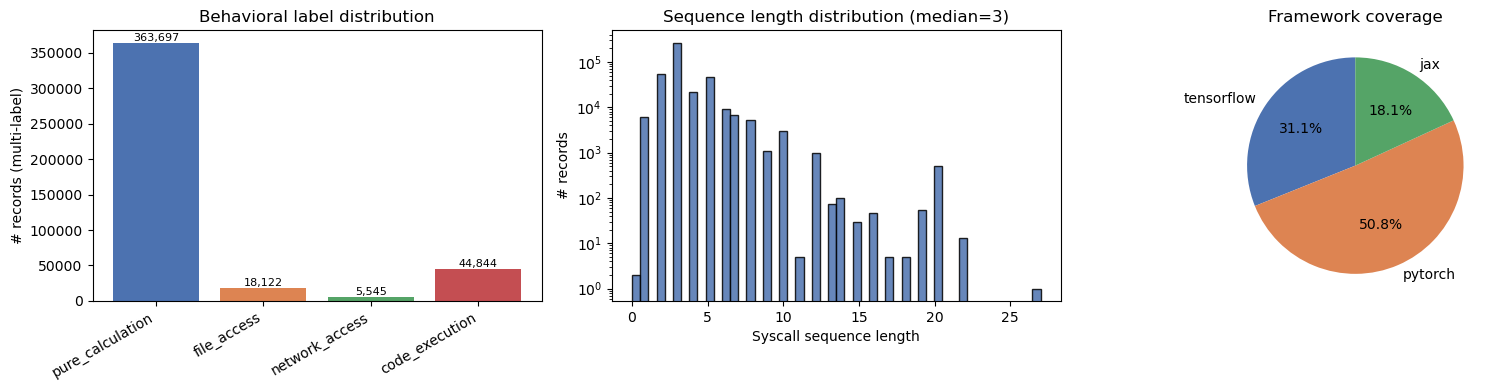

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
ax = axes[0]
labels = list(label_counts.keys())
counts = [label_counts[l] for l in labels]
bars = ax.bar(range(len(labels)), counts, color=['#4C72B0','#DD8452','#55A467','#C44E52','#8172B2'])
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('# records (multi-label)')
ax.set_title('Behavioral label distribution')
for b,c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{c:,}', ha='center', va='bottom', fontsize=8)

# Sequence lengths
ax = axes[1]
ax.hist(seq_lens, bins=50, color='#4C72B0', edgecolor='black', alpha=0.85)
ax.set_xlabel('Syscall sequence length')
ax.set_ylabel('# records')
ax.set_title(f'Sequence length distribution (median={int(sorted(seq_lens)[len(seq_lens)//2])})')
ax.set_yscale('log')

# Framework distribution
ax = axes[2]
fws = list(framework_counts.keys())
fcs = [framework_counts[f] for f in fws]
ax.pie(fcs, labels=fws, autopct='%1.1f%%', startangle=90, colors=['#4C72B0','#DD8452','#55A467','#C44E52'])
ax.set_title('Framework coverage')

plt.tight_layout()
plt.show()
